# AI Engineer Roadmap
## AI Engineering Concepts
### https://zazencodes.com/courses/ai-engineer-roadmap#ai-engineering-concepts

## Figures

The code below was used to generate plots to include as figures in the lessons.

In [1]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

model = GPT2LMHeadModel.from_pretrained("gpt2")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

input_text = "The future of AI is"
input_ids = tokenizer.encode(input_text, return_tensors="pt")

output = model.generate(
    input_ids,
    max_length=50,
    temperature=0.7,
    top_p=0.9,
    do_sample=True
)

print(tokenizer.decode(output[0], skip_special_tokens=True))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


The future of AI is in its infancy. It's not yet clear how much the future will include artificial intelligence. But it's going to be interesting to see how the next two decades unfold.

Follow me on Twitter.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Rectangle
import torch
import torch.nn.functional as F

# Dracula theme colors
BG_COLOR = '#282a36'  # Dark background
FG_COLOR = '#f8f8f2'  # Light foreground text
PURPLE   = '#BD93F9'  # Primary color
ORANGE   = '#FFB86C'  # Secondary color
PINK     = '#FF79C6'  # Tertiary color
GREEN    = '#50FA7B'  # Additional color
CYAN     = '#8BE9FD'  # Additional color

def style_axes(ax):
    """Apply Dracula styling to axes."""
    ax.set_facecolor(BG_COLOR)
    ax.tick_params(colors=FG_COLOR)
    for spine in ax.spines.values():
        spine.set_color(FG_COLOR)

# Set global matplotlib settings for Dracula theme
plt.rcParams['figure.facecolor'] = BG_COLOR
plt.rcParams['axes.facecolor'] = BG_COLOR
plt.rcParams['axes.edgecolor'] = FG_COLOR
plt.rcParams['axes.labelcolor'] = FG_COLOR
plt.rcParams['xtick.color'] = FG_COLOR
plt.rcParams['ytick.color'] = FG_COLOR
plt.rcParams['text.color'] = FG_COLOR


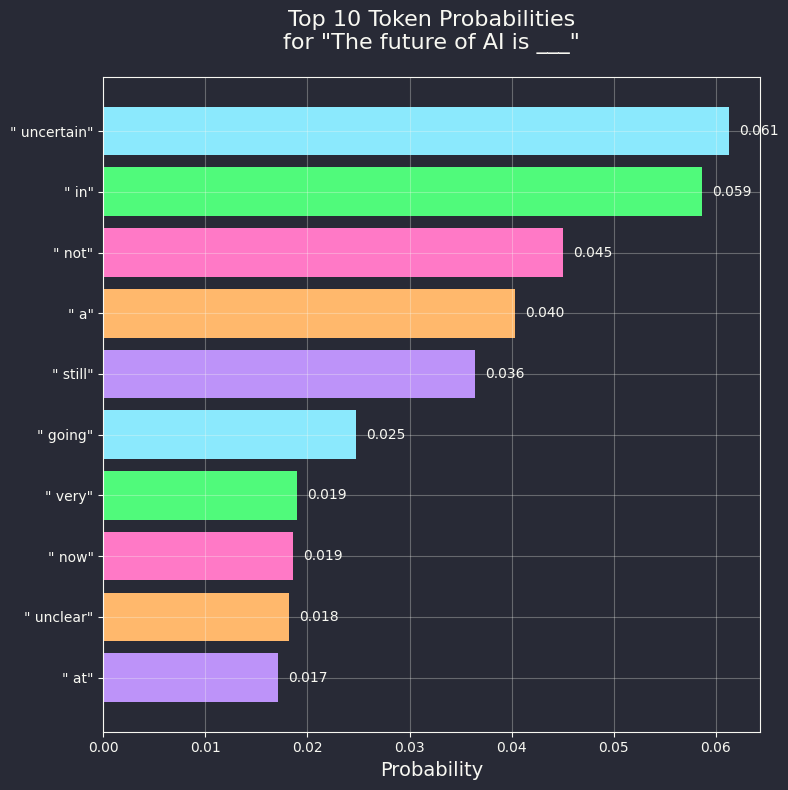

In [25]:
# Visualization 1: Token Probability Distribution
def visualize_token_probabilities(input_text):
    """Visualize top token probabilities for next token prediction."""
    
    # Get model predictions for the input
    input_ids = tokenizer.encode(input_text, return_tensors="pt")
    
    with torch.no_grad():
        outputs = model(input_ids)
        logits = outputs.logits[0, -1, :]  # Get logits for last token
        probs = F.softmax(logits, dim=-1)
    
    # Get top 10 tokens
    top_probs, top_indices = torch.topk(probs, 10)
    top_probs = top_probs.flip(0)
    top_indices = top_indices.flip(0)
    top_tokens = [tokenizer.decode([idx]) for idx in top_indices]
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(8, 8))
    fig.patch.set_facecolor(BG_COLOR)
    
    # Create horizontal bar chart
    y_pos = np.arange(len(top_tokens))
    bars = ax.barh(y_pos, top_probs.cpu().numpy(), 
                   color=[PURPLE, ORANGE, PINK, GREEN, CYAN] * 2,
    )
    
    # Customize plot
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f'"{token}"' for token in top_tokens])
    ax.set_xlabel('Probability', fontsize=14, color=FG_COLOR)
    ax.set_title(f'Top 10 Token Probabilities\nfor "{input_text} ___"', 
                 fontsize=16, color=FG_COLOR, pad=20)
    
    # Add probability values on bars
    for i, (bar, prob) in enumerate(zip(bars, top_probs)):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, 
                f'{prob:.3f}', va='center', color=FG_COLOR, fontsize=10)
    
    style_axes(ax)
    ax.grid(True, alpha=0.3, color=FG_COLOR)
    
    plt.tight_layout()
    plt.show()

visualize_token_probabilities("The future of AI is")


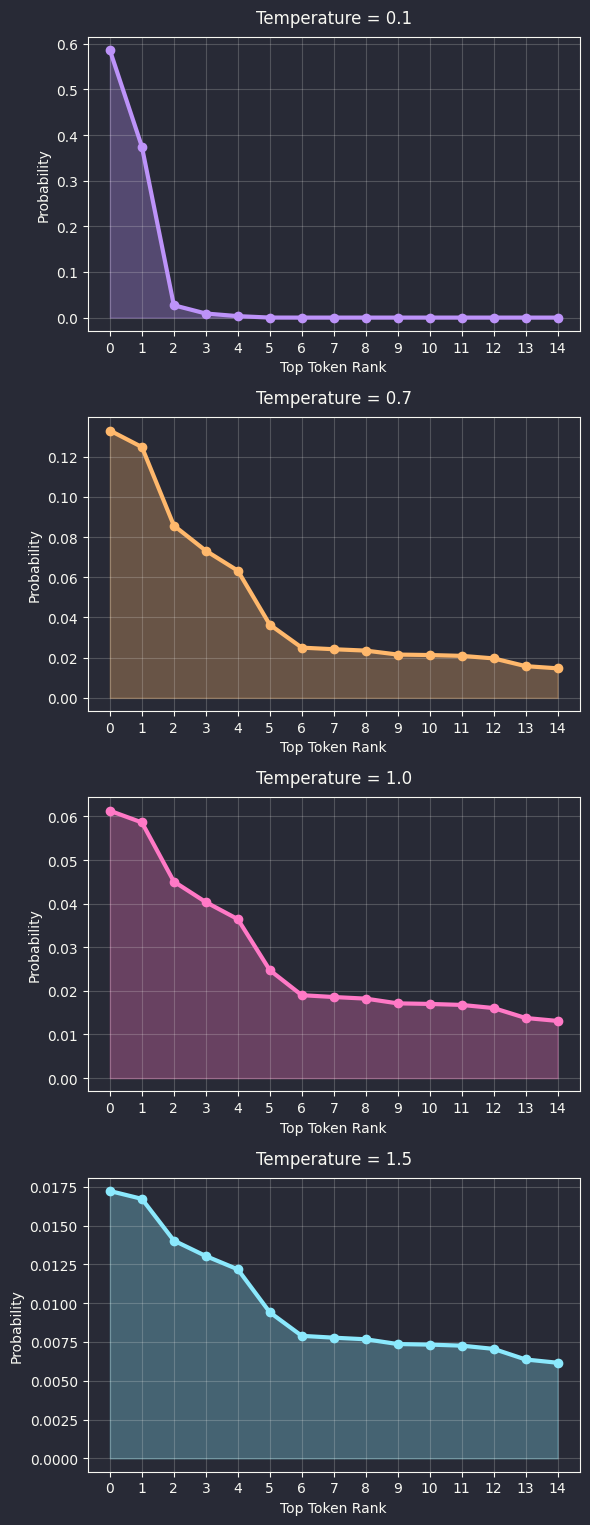

In [17]:
# Visualization 2: Temperature Effect on Generation
def visualize_temperature_effect():
    """Show how temperature affects the probability distribution."""

    input_text = "The future of AI is"
    input_ids = tokenizer.encode(input_text, return_tensors="pt")

    with torch.no_grad():
        outputs = model(input_ids)
        logits = outputs.logits[0, -1, :]

    temperatures = [0.1, 0.7, 1.0, 1.5]

    fig, axes = plt.subplots(len(temperatures), 1, figsize=(6, 16))
    fig.patch.set_facecolor(BG_COLOR)
    # fig.suptitle('Effect of Temperature on Token Probability Distribution', 
    #              fontsize=13, color=FG_COLOR, y=0.96)

    colors = [PURPLE, ORANGE, PINK, CYAN]

    for i, (temp, ax, color) in enumerate(zip(temperatures, axes, colors)):
        # Apply temperature scaling
        scaled_logits = logits / temp
        probs = F.softmax(scaled_logits, dim=-1)

        # Get top 15 for visualization
        top_probs, top_indices = torch.topk(probs, 15)

        # Plot as line chart to show distribution shape
        x = np.arange(len(top_probs))
        y = top_probs.cpu().numpy()
        ax.plot(x, y, color=color, linewidth=3, marker='o', markersize=6)
        ax.fill_between(x, y, alpha=0.3, color=color)

        ax.set_title(f'Temperature = {temp}', fontsize=12, color=FG_COLOR, pad=10)
        ax.set_xlabel('Top Token Rank', fontsize=10, color=FG_COLOR)
        ax.set_ylabel('Probability', fontsize=10, color=FG_COLOR)

        # Set integer ticks on x-axis
        ax.set_xticks(np.arange(len(top_probs)))

        style_axes(ax)
        ax.grid(True, alpha=0.2, color=FG_COLOR)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


visualize_temperature_effect()


 0  The
 1  Ġeagle
 2  Ġsoared
 3  Ġgrace
 4  fully
 5  Ġabove
 6  Ġthe
 7  Ġancient
 8  Ġforest


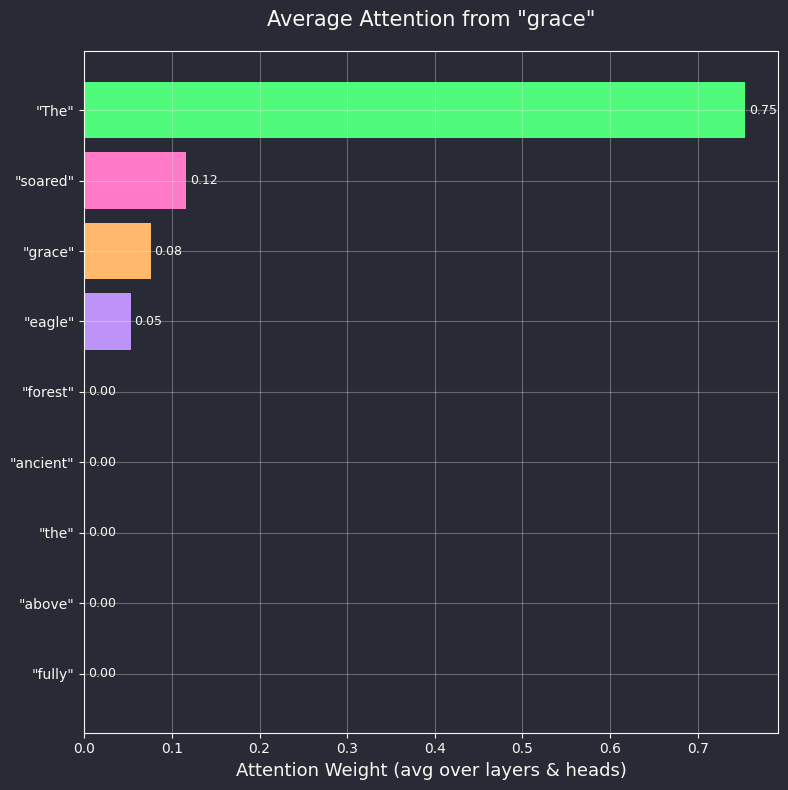

In [41]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def visualize_avg_attention(sentence,
                            model,
                            tokenizer,
                            target_subtoken="Ġgrace",
                            layer_filter=None):
    """
    Plot the attention weights FROM `target_subtoken` TO every token in `sentence`,
    averaging over *all* layers & heads (or a user‑supplied subset of layers).

    Parameters
    ----------
    sentence : str
        The raw text you want to analyse.
    model : PreTrainedModel
        The loaded GPT‑2 (or compatible) model.
    tokenizer : PreTrainedTokenizer
        Matching tokenizer.
    target_subtoken : str, default "Ġgrace"
        Exact sub‑token to act as the *query* position.
    layer_filter : list[int] | None
        If supplied, average only over these layer indices.
        By default, averages over *all* layers.
    """

    # 1  Encode input and run model with attentions
    enc = tokenizer(sentence, return_tensors="pt", add_special_tokens=False)
    input_ids = enc["input_ids"]                    # shape (1, seq_len)

    with torch.no_grad():
        outputs = model(input_ids, output_attentions=True)
        # outputs.attentions: tuple[num_layers] of (1, n_heads, seq, seq)
        attn_tensor = torch.stack(outputs.attentions)        # (L, 1, H, S, S)
        attn_tensor = attn_tensor.squeeze(1)                 # (L, H, S, S)

    # Optionally restrict to selected layers
    if layer_filter is not None:
        attn_tensor = attn_tensor[layer_filter]

    # 2  Average across layers *and* heads  →  (seq, seq)
    avg_attn = attn_tensor.mean(dim=(0, 1))                  # (S, S)

    # 3  Locate the focus token index
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])   # list[str] length S
    if target_subtoken not in tokens:
        raise ValueError(f"'{target_subtoken}' not found in: {tokens}")
    focus_ix = tokens.index(target_subtoken)

    # 4  Extract the attention weights FROM focus token TO all tokens
    weights = avg_attn[focus_ix].cpu().numpy()               # (S,)

    # 5  Prepare data for bar‑plot (sort for readability)
    sort_idx = np.argsort(weights)
    sorted_tokens  = [tokens[i].lstrip("Ġ")   for i in sort_idx]
    sorted_weights = [weights[i]              for i in sort_idx]
    colours = [PURPLE, ORANGE, PINK, GREEN, CYAN] * 10

    # 6  Plot
    fig, ax = plt.subplots(figsize=(8, 8))
    fig.patch.set_facecolor(BG_COLOR)

    y = np.arange(len(sorted_tokens))
    bars = ax.barh(y, sorted_weights, color=colours[:len(sorted_tokens)])

    for bar, w in zip(bars, sorted_weights):
        ax.text(bar.get_width() + 0.004,
                bar.get_y() + bar.get_height()/2,
                f"{w:.2f}",
                va="center", fontsize=9, color=FG_COLOR)

    ax.set_yticks(y)
    ax.set_yticklabels([f'"{tok}"' for tok in sorted_tokens])
    ax.set_xlabel("Attention Weight (avg over layers & heads)", fontsize=13)
    ax.set_title(f'Average Attention from "{target_subtoken.lstrip("Ġ")}"',
                 fontsize=15, pad=18)

    style_axes(ax)
    ax.grid(True, alpha=0.3, color=FG_COLOR)
    plt.tight_layout(); plt.show()


from transformers import GPT2LMHeadModel, GPT2TokenizerFast

model      = GPT2LMHeadModel.from_pretrained("gpt2")
tokenizer  = GPT2TokenizerFast.from_pretrained("gpt2")
model.eval()

tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
for i, tok in enumerate(tokens):
    print(f"{i:>2}  {tok}")

sentence = "The eagle soared gracefully above the ancient forest"
visualize_avg_attention(sentence, model, tokenizer, target_subtoken="Ġgrace")



In [2]:
# dracula_style.py
import matplotlib.pyplot as plt

# Dracula theme colors
BG_COLOR = '#282a36'  # Dark background
FG_COLOR = '#f8f8f2'  # Light foreground text
PURPLE   = '#BD93F9'  # Primary color
ORANGE   = '#FFB86C'  # Secondary color
PINK     = '#FF79C6'  # Tertiary color
GREEN    = '#50FA7B'  # Additional color
CYAN     = '#8BE9FD'  # Additional color

plt.rcParams.update(
    {
        "figure.facecolor": BG_COLOR,
        "axes.facecolor"  : BG_COLOR,
        "axes.edgecolor"  : FG_COLOR,
        "axes.labelcolor" : FG_COLOR,
        "xtick.color"     : FG_COLOR,
        "ytick.color"     : FG_COLOR,
        "text.color"      : FG_COLOR,
        "axes.prop_cycle" : plt.cycler(color=[PURPLE, ORANGE, PINK, CYAN, GREEN]),
        "grid.color"      : FG_COLOR,
        "grid.alpha"      : 0.3,
        "grid.linestyle"  : "--",
    }
)

def style_axes(ax, edgecolor=FG_COLOR, linewidth=1.2):
    ax.set_facecolor(BG_COLOR)
    ax.tick_params(colors=FG_COLOR)
    for spine in ax.spines.values():
        spine.set_color(FG_COLOR)
    for patch in ax.patches:
        if hasattr(patch, "get_facecolor"):
            face = patch.get_facecolor()
            patch.set_edgecolor(edgecolor or face)
            patch.set_linewidth(linewidth)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/alex/pro/ai-engineer-roadmap-notebooks/.venv/lib/python3.12/site-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,0.743500,0.635698
2,0.657700,0.559686
3,0.549600,0.538697


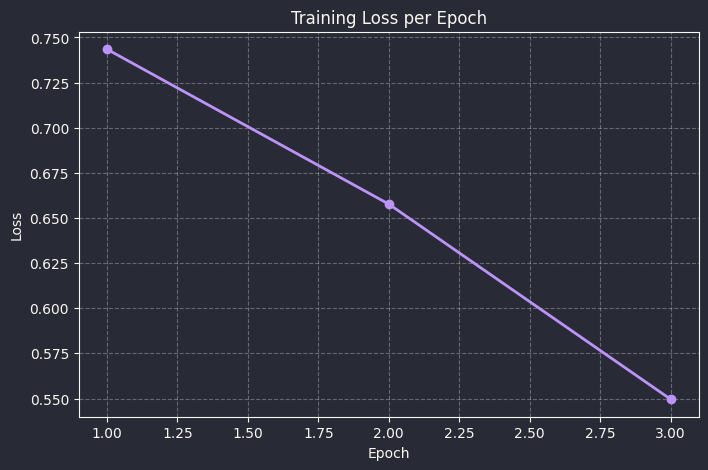

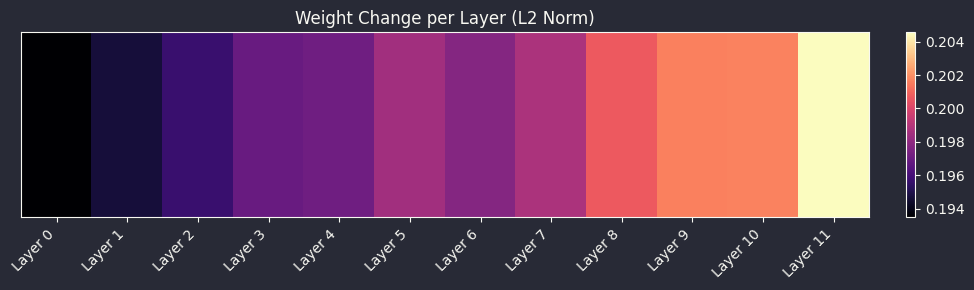

In [23]:
from transformers import Trainer, TrainingArguments, AutoModelForSequenceClassification, AutoTokenizer
from datasets import Dataset
import os
os.environ["WANDB_MODE"] = "disabled"

# make_plots_from_real_run.py
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from transformers import (
    Trainer,
    TrainingArguments,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    TrainerCallback,
)
from datasets import Dataset
from sklearn.metrics import confusion_matrix

# ------------------------- Config -------------------------
MODEL_NAME = "bert-base-uncased"

seed = 137
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------- Data (tiny demo) -------------------
train_texts = [
    "This movie was dope, I loved every minute of it!",
    "Trashhhh",
    "A masterpiece of modern cinema. Totally sick",
    "I fell asleep halfway through, very boring."
]
train_labels = [1, 0, 1, 0]

test_texts = [
    "This film was an absolute joy to watch!",
    "Horrible experience, never watching this again.",
    "It was okay, not great but not terrible either."
]

# ------------------- Tokenizer / Model --------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
original_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

original_state = {k: v.cpu().clone() for k, v in original_model.state_dict().items()}

# Prepare datasets
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=512)
train_encodings.update({"labels": train_labels})
train_dataset = Dataset.from_dict(train_encodings)

# ---------------- Loss logger to get *real* epoch losses ----
class EpochLossLogger(TrainerCallback):
    def __init__(self):
        self.step_logs = []  # (epoch, loss)

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None and "loss" in logs and "epoch" in logs:
            self.step_logs.append((float(logs["epoch"]), float(logs["loss"])))

    def get_epoch_losses(self):
        # take the last logged loss for each epoch
        epoch_to_loss = {}
        for ep, loss in self.step_logs:
            epoch_to_loss[ep] = loss
        epochs = sorted(epoch_to_loss.keys())
        losses = [epoch_to_loss[ep] for ep in epochs]
        return np.array(epochs), np.array(losses)

epoch_cb = EpochLossLogger()

training_args = TrainingArguments(
    evaluation_strategy="epoch",
    per_device_train_batch_size=8,
    num_train_epochs=3,
    save_steps=10_000,
    save_total_limit=2,
    logging_steps=1,
    report_to=[]  # silence WandB/Comet, etc.
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=train_dataset,  # demo only
    callbacks=[epoch_cb],
)

# ---------------------- Train -----------------------------
trainer.train()

# Real epoch losses
epochs, train_losses = epoch_cb.get_epoch_losses()

# Updated weights
updated_state = {k: v.cpu() for k, v in model.state_dict().items()}

# ---------------- Weight deltas per layer -----------------
# We'll compute an L2 norm per encoder layer (0..11) on the attention + intermediate + output weights.
layer_diffs = []
for i in range(12):
    prefix = f"bert.encoder.layer.{i}."
    sq_sum = 0.0
    count = 0
    for k in updated_state:
        if k.startswith(prefix) and k in original_state:
            diff = (updated_state[k] - original_state[k]).float()
            sq_sum += (diff ** 2).sum().item()
            count += diff.numel()
    layer_diffs.append(np.sqrt(sq_sum))  # raw L2 per layer

layers = [f"Layer {i}" for i in range(12)]
layer_diffs = np.array(layer_diffs)

# ----------------- Inference on test set ------------------
inputs = tokenizer(test_texts, truncation=True, padding=True, max_length=512, return_tensors="pt")
model.eval()
with torch.no_grad():
    outputs = model(**{k: v.to(model.device) for k, v in inputs.items()})
    logits = outputs.logits.detach().cpu()
probs = F.softmax(logits, dim=-1).numpy()
preds = probs.argmax(axis=-1)

# ---------------- Confusion matrix on train ----------------
pred_train = trainer.predict(train_dataset)
y_true = pred_train.label_ids
y_pred = pred_train.predictions.argmax(-1)
cm = confusion_matrix(y_true, y_pred)

# ---------------- Token length distribution ---------------
# WordPiece counts (attention mask sum) for all texts
all_texts = train_texts + test_texts
all_enc = tokenizer(all_texts, truncation=True, padding=True, max_length=512, return_tensors="pt")
token_lengths = all_enc["attention_mask"].sum(dim=1).cpu().numpy()

# ----------------- Class distribution ---------------------
neg_count = train_labels.count(0)
pos_count = train_labels.count(1)

# ==========================================================
# =====================   PLOTTING   =======================
# ==========================================================

# 1) Training loss
fig, ax = plt.subplots(figsize=(8, 5))
style_axes(ax)
ax.plot(epochs, train_losses, marker="o", linewidth=2, color=PURPLE)
ax.set_title("Training Loss per Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(alpha=0.3, color=FG_COLOR, linestyle="--")

# 4) Weight change heatmap
fig, ax = plt.subplots(figsize=(10, 3))
style_axes(ax)
heat = ax.imshow(layer_diffs.reshape(1, -1), aspect="auto", cmap="magma")
ax.set_xticks(np.arange(len(layers)))
ax.set_xticklabels(layers, rotation=45, ha="right")
ax.set_yticks([])
ax.set_title("Weight Change per Layer (L2 Norm)")
plt.colorbar(heat, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()




In [11]:
from gensim.downloader import load
import numpy as np

# Load pre-trained Word2Vec embeddings trained on news data
model = load('word2vec-google-news-300')

# Get the embeddings for 'cat' and 'dog'
cat_vector = model.get_vector('cat')
dog_vector = model.get_vector('dog')


# Calculate cosine similarity between the vectors
similarity = np.dot(cat_vector, dog_vector) / (np.linalg.norm(cat_vector) * np.linalg.norm(dog_vector))

print(f"Cosine similarity between 'cat' and 'dog': {similarity:.4f}")

# Let's also find some of the most similar words to 'dog'
similar_words = model.most_similar('dog', topn=5)
print("\nMost similar words to 'dog':")
for word, score in similar_words:
    print(f"{word}: {score:.4f}")

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Cosine similarity between 'cat' and 'dog': 0.7609

Most similar words to 'dog':
dogs: 0.8680
puppy: 0.8106
pit_bull: 0.7804
pooch: 0.7627
cat: 0.7609


In [12]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
model = AutoModel.from_pretrained('bert-base-uncased')

def get_word_embedding(sentence, word):
    # Tokenize the sentence and find the position of our target word
    inputs = tokenizer(sentence, return_tensors="pt")
    word_tokens = tokenizer.tokenize(word)
    sentence_tokens = tokenizer.tokenize(sentence)

    # Find position of the word in tokenized sentence
    word_start = None
    for i in range(len(sentence_tokens)):
        if sentence_tokens[i] == word_tokens[0]:
            word_start = i + 1  # Add 1 for [CLS] token
            break

    # Get model output
    with torch.no_grad():
        outputs = model(**inputs)

    # Get embedding for the word (using first token if word is split into subwords)
    word_embedding = outputs.last_hidden_state[0, word_start]
    return F.normalize(word_embedding, p=2, dim=0)  # Normalize the vector

# Get embeddings for 'bank' in different contexts
river_bank_emb = get_word_embedding("The river bank was muddy", "bank")
financial_bank_emb_1 = get_word_embedding("The financial bank was closed", "bank")
financial_bank_emb_2 = get_word_embedding("The financial bank was open", "bank")

print("Printing the first 5 embedding dimensions")
print(f"bank (river context):   {river_bank_emb[:5]}")
print(f"bank (finance context): {financial_bank_emb_1[:5]}")
print(f"bank (finance context): {financial_bank_emb_2[:5]}")


Printing the first 5 embedding dimensions
bank (river context):   tensor([-0.0213, -0.0281,  0.0011, -0.0185, -0.0047])
bank (finance context): tensor([ 0.0177, -0.0184,  0.0143, -0.0092,  0.0314])
bank (finance context): tensor([-0.0012, -0.0216,  0.0067, -0.0240,  0.0437])


In [13]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

# Load GPT-2 model and tokenizer
tokenizer = AutoTokenizer.from_pretrained('gpt2')
model = AutoModel.from_pretrained('gpt2')

def get_word_embedding(sentence, word):
    # Tokenize the sentence and find the position of our target word
    inputs = tokenizer(sentence, return_tensors="pt", add_special_tokens=False)
    sentence_tokens = tokenizer.tokenize(sentence)
    
    # GPT-2 uses space prefixes (Ġ) for words after whitespace in BPE tokenization
    word_tokens = tokenizer.tokenize(" " + word)  # Ensure correct BPE tokenization

    # Find position of the first token of the word in the tokenized sentence
    word_start = None
    for i in range(len(sentence_tokens) - len(word_tokens) + 1):
        if sentence_tokens[i:i + len(word_tokens)] == word_tokens:
            word_start = i
            break

    if word_start is None:
        raise ValueError(f"Word '{word}' not found in tokenized sentence.")

    # Get model output
    with torch.no_grad():
        outputs = model(**inputs)

    # Extract embedding for the first token of the target word
    word_embedding = outputs.last_hidden_state[0, word_start]
    return F.normalize(word_embedding, p=2, dim=0)  # Normalize the vector

# Get embeddings for 'bank' in different contexts
river_bank_emb = get_word_embedding("The river bank was muddy", "bank")
financial_bank_emb_1 = get_word_embedding("The financial bank was closed", "bank")
financial_bank_emb_2 = get_word_embedding("The financial bank was open", "bank")

print("Printing the first 5 embedding dimensions")
print(f"bank (river context):   {river_bank_emb[:5]}")
print(f"bank (finance context): {financial_bank_emb_1[:5]}")
print(f"bank (finance context): {financial_bank_emb_2[:5]}")

Printing the first 5 embedding dimensions
bank (river context):   tensor([-0.0034,  0.0017, -0.0055,  0.0025,  0.0011])
bank (finance context): tensor([-1.5110e-03,  1.7307e-05, -4.1355e-03,  1.4719e-03,  2.1846e-03])
bank (finance context): tensor([-1.5110e-03,  1.7307e-05, -4.1355e-03,  1.4719e-03,  2.1846e-03])


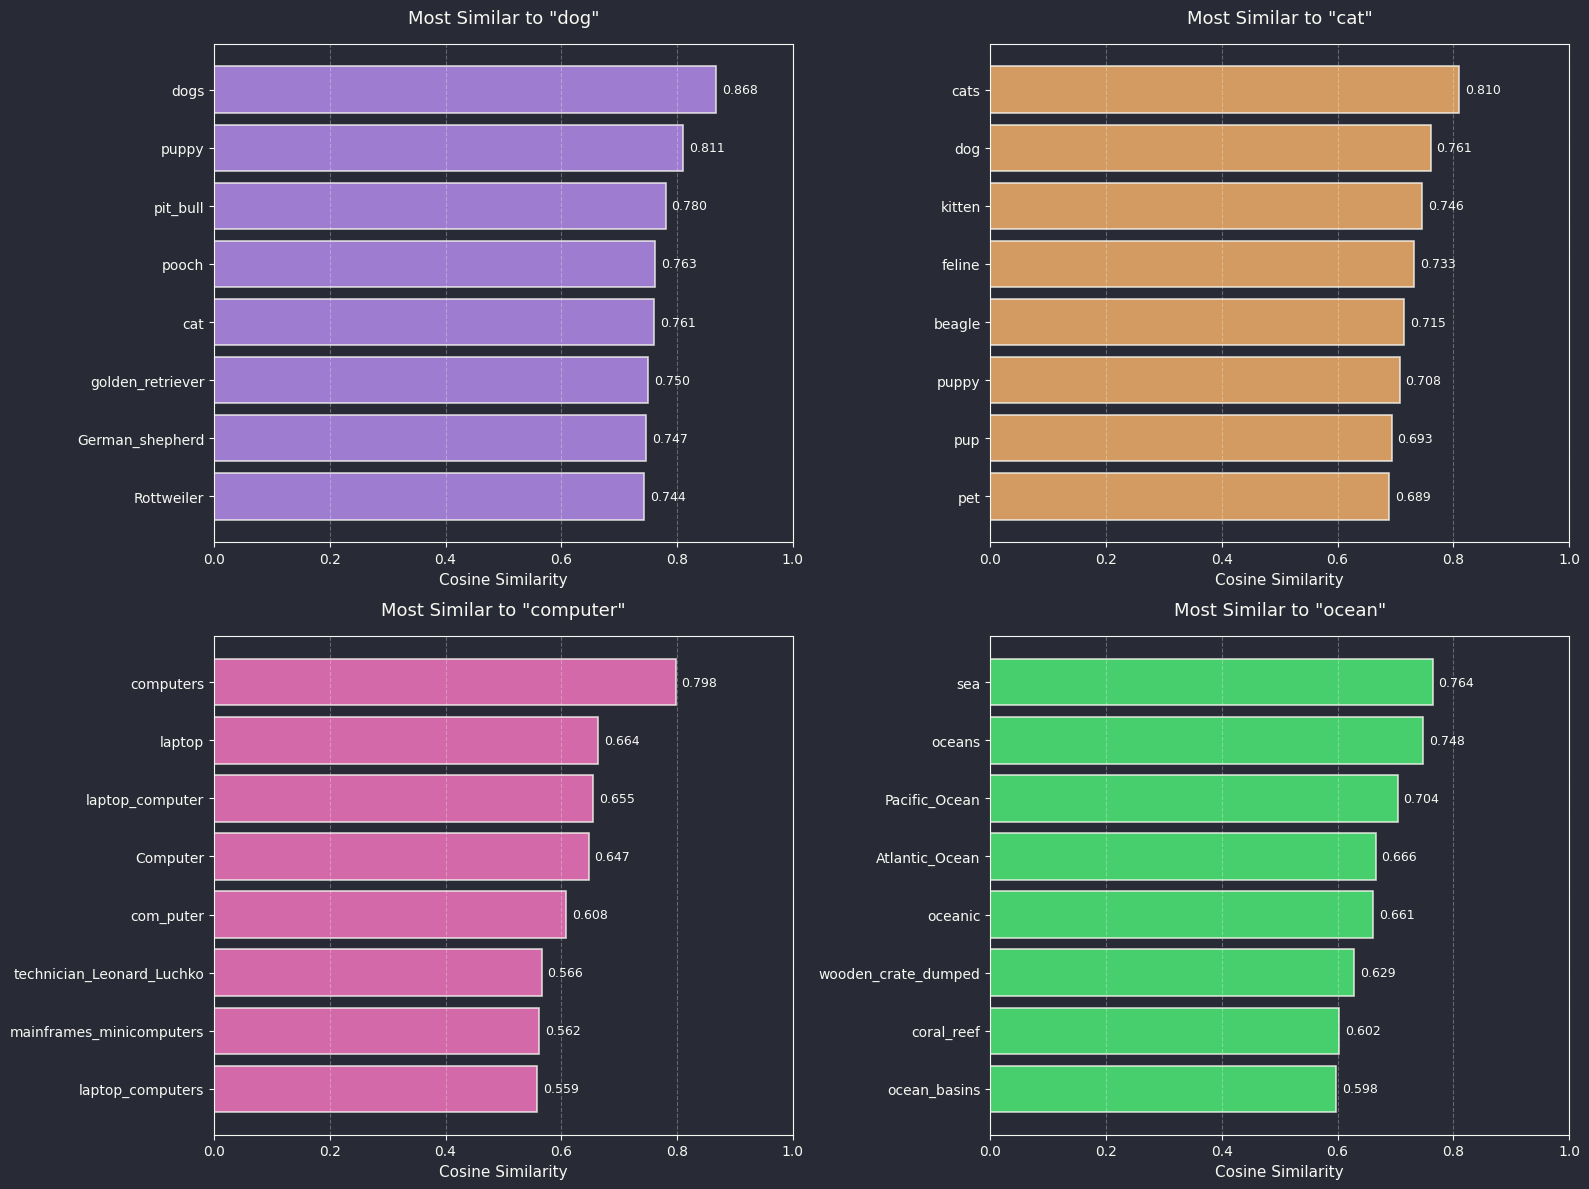

In [24]:
# Visualization: Word2Vec Similarity Analysis
def visualize_word2vec_similarities():
    """Visualize Word2Vec similarity relationships."""
    from gensim.downloader import load
    import numpy as np
    
    # Load pre-trained Word2Vec embeddings
    w2v_model = load('word2vec-google-news-300')
    
    # Define target words and their similar words
    target_words = ['dog', 'cat', 'computer', 'ocean']
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.patch.set_facecolor(BG_COLOR)
    # fig.suptitle('Word2Vec Similarity Analysis', fontsize=18, color=FG_COLOR, y=0.95)
    
    colors = [PURPLE, ORANGE, PINK, GREEN]
    
    for idx, (word, ax, color) in enumerate(zip(target_words, axes.flat, colors)):
        try:
            # Get most similar words
            similar_words = w2v_model.most_similar(word, topn=8)
            words = [item[0] for item in similar_words][::-1]
            scores = [item[1] for item in similar_words][::-1]
            
            # Create horizontal bar chart
            y_pos = np.arange(len(words))
            bars = ax.barh(y_pos, scores, color=color, alpha=0.8)
            
            # Customize plot
            ax.set_yticks(y_pos)
            ax.set_yticklabels(words)
            ax.set_xlabel('Cosine Similarity', fontsize=11, color=FG_COLOR)
            ax.set_title(f'Most Similar to "{word}"', fontsize=13, color=FG_COLOR, pad=15)
            
            # Add score labels
            for bar, score in zip(bars, scores):
                ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                       f'{score:.3f}', va='center', color=FG_COLOR, fontsize=9)
            
            style_axes(ax)
            ax.grid(True, alpha=0.3, color=FG_COLOR, axis='x')
            ax.set_xlim(0, 1.0)
            
        except KeyError:
            ax.text(0.5, 0.5, f'"{word}" not found\nin vocabulary', 
                   ha='center', va='center', transform=ax.transAxes, 
                   color=FG_COLOR, fontsize=12)
            style_axes(ax)
    
    plt.tight_layout()
    plt.show()

visualize_word2vec_similarities()


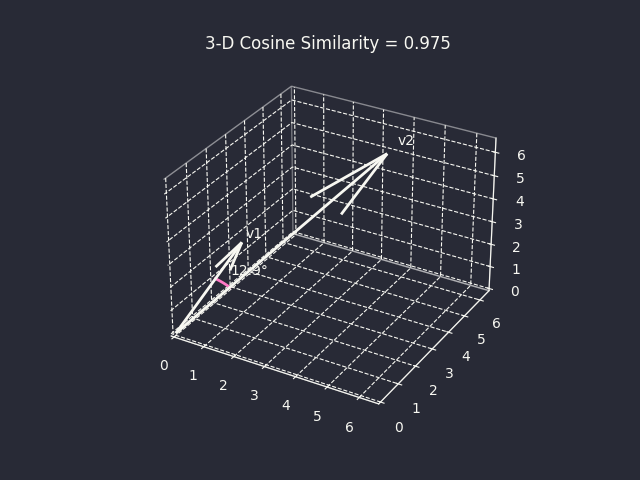

In [34]:
%matplotlib ipympl

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3‑D)

# ---------------------------------------------------------------------------#
v1 = np.array([1, 2, 3])
v2 = np.array([4, 5, 6])
origin = np.zeros(3)

cos_sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
theta   = np.arccos(cos_sim)          # radians

# helpers for the arc (lies in the plane spanned by v1 and v2) -------------
v1_u   = v1 / np.linalg.norm(v1)
v2_u   = v2 / np.linalg.norm(v2)
normal = np.cross(v1_u, v2_u)
normal /= np.linalg.norm(normal)
# an orthonormal basis of the plane
u = v1_u
v = np.cross(normal, u)
angle = np.linspace(0, theta, 100)
r     = 0.6 * min(np.linalg.norm(v1), np.linalg.norm(v2))
arc   = (u[np.newaxis, :] * np.cos(angle)[:, None] +
         v[np.newaxis, :] * np.sin(angle)[:, None]) * r

# ---------------------------------------------------------------------------#
fig = plt.figure()
ax  = fig.add_subplot(111, projection="3d")
style_axes(ax)       # Dracula styling for axis ticks / spines

# extra Dracula touches for the 3‑D panes
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor(BG_COLOR)
    axis._axinfo["grid"]["color"] = FG_COLOR

# vectors
ax.quiver(*origin, *v1, color=FG_COLOR, linewidth=2)
ax.quiver(*origin, *v2, color=FG_COLOR, linewidth=2)
ax.plot(arc[:, 0], arc[:, 1], arc[:, 2], color=PINK, linewidth=2)

# labels
ax.text(*(v1 * 1.05), "v1", color=FG_COLOR)
ax.text(*(v2 * 1.05), "v2", color=FG_COLOR)
ax.text(*(arc[len(angle)//2] * 1.15), f"{np.degrees(theta):.1f}°", color=FG_COLOR)

# limits & title
m = max(np.abs(np.concatenate([v1, v2])))
ax.set_xlim(-0.1, m*1.1)
ax.set_ylim(-0.1, m*1.1)
ax.set_zlim(-0.1, m*1.1)
ax.set_title(f"3‑D Cosine Similarity = {cos_sim:.3f}")
plt.show()


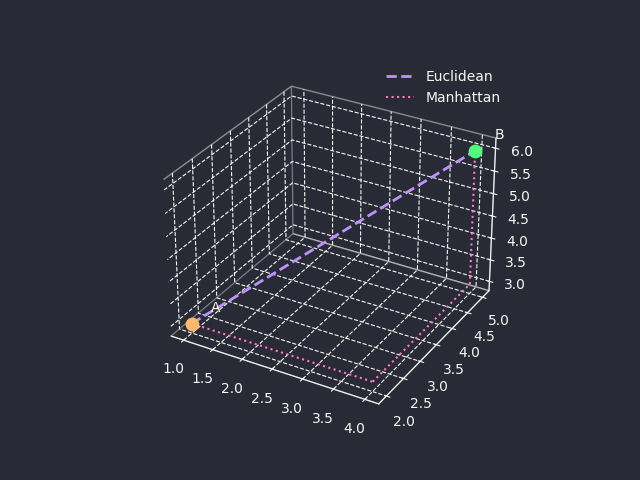

In [39]:

%matplotlib ipympl

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# points
A = np.array([1, 2, 3])
B = np.array([4, 5, 6])

euclid   = np.linalg.norm(A - B)
manhat   = np.sum(np.abs(A - B))

# Manhattan bend points (A → (Bx,Ay,Az) → (Bx,By,Az) → B) -------------------
P1 = np.array([B[0], A[1], A[2]])
P2 = np.array([B[0], B[1], A[2]])

fig = plt.figure()
ax  = fig.add_subplot(111, projection="3d")
style_axes(ax)
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor(BG_COLOR)
    axis._axinfo["grid"]["color"] = FG_COLOR

# scatter points
ax.scatter(*A, color=ORANGE, s=80)
ax.scatter(*B, color=GREEN,  s=80)

# Euclidean path
ax.plot([A[0], B[0]], [A[1], B[1]], [A[2], B[2]],
        linestyle="--", label="Euclidean", linewidth=2)

# Manhattan path (orthogonal segments)
ax.plot([A[0], P1[0]], [A[1], P1[1]], [A[2], P1[2]], linestyle=":", color=PINK)
ax.plot([P1[0], P2[0]], [P1[1], P2[1]], [P1[2], P2[2]], linestyle=":", color=PINK)
ax.plot([P2[0], B[0]], [P2[1], B[1]], [P2[2], B[2]], linestyle=":", label="Manhattan", color=PINK)

# labels
ax.text(*(A + 0.2), "A", color=FG_COLOR)
ax.text(*(B + 0.2), "B", color=FG_COLOR)

ax.legend(frameon=False)
plt.show()


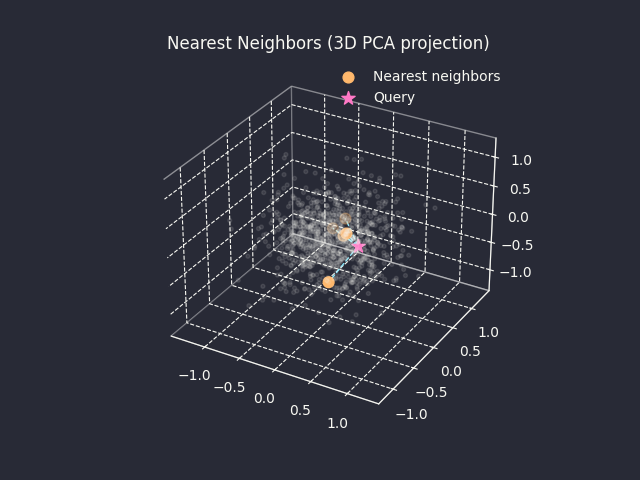

In [42]:

%matplotlib ipympl

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import faiss


# ---------------------------------------------------------------------------#
np.random.seed(0)
data  = np.random.random((1000, 128)).astype("float32")
query = np.random.random((1, 128)).astype("float32")

index = faiss.IndexFlatL2(128)
index.add(data)

k = 5
distances, nn_idx = index.search(query, k)   # nn_idx shape (1,k)

# ---------------------------------------------------------------------------#
# Dimensionality reduction to 3‑D for visualisation
pca          = PCA(n_components=3, random_state=0)
reduced_all  = pca.fit_transform(np.vstack([query, data]))
query_3d     = reduced_all[0]
data_3d      = reduced_all[1:]
nn_points_3d = data_3d[nn_idx[0]]

# ---------------------------------------------------------------------------#
fig = plt.figure()
ax  = fig.add_subplot(111, projection="3d")
style_axes(ax)
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor(BG_COLOR)
    axis._axinfo["grid"]["color"] = FG_COLOR

# plot background points (faint)
ax.scatter(data_3d[:, 0], data_3d[:, 1], data_3d[:, 2],
           s=8, alpha=0.1, color=FG_COLOR)

# plot nearest neighbors
ax.scatter(nn_points_3d[:, 0], nn_points_3d[:, 1], nn_points_3d[:, 2],
           s=60, color=ORANGE, label="Nearest neighbors")

# plot query point
ax.scatter(*query_3d, s=100, color=PINK, marker="*", label="Query")

# dashed lines from query to each neighbor for visual distance reference
for pt in nn_points_3d:
    ax.plot([query_3d[0], pt[0]],
            [query_3d[1], pt[1]],
            [query_3d[2], pt[2]],
            linestyle="--", linewidth=1, color=CYAN)

ax.set_title("Nearest Neighbors (3D PCA projection)")
ax.legend(frameon=False)
plt.show()


Text-Image Similarity: 0.35


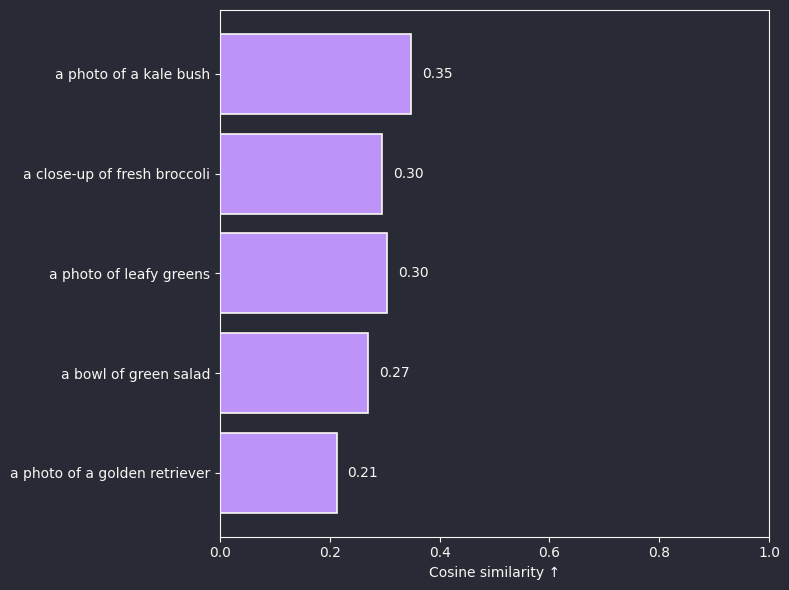

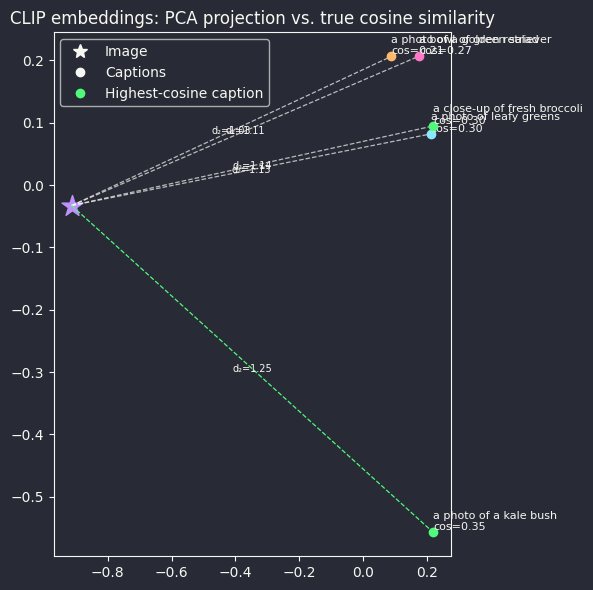

In [13]:
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import requests
from io import BytesIO

# Load a pre-trained CLIP model
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

kale_image_url = "https://upload.wikimedia.org/wikipedia/commons/2/20/Boerenkool.jpg"
kale_image_resp = requests.get(kale_image_url, headers={"User-Agent": "Mozilla/5.0"})
kale_image_resp.raise_for_status()
kale_image = Image.open(BytesIO(kale_image_resp.content))
caption = "a photo of a kale bush"

# Input text and image
inputs = processor(text=[caption], images=[kale_image], return_tensors="pt", padding=True)

# Get embeddings
outputs = model(**inputs)
text_embeddings = outputs.text_embeds
image_embeddings = outputs.image_embeds

# Compute similarity
similarity = torch.cosine_similarity(text_embeddings, image_embeddings)
print(f"Text-Image Similarity: {similarity.item():.2f}")


# ░░ CLIP Similarity Visualizations  ░░
# Assumes: `model`, `processor`, `kale_image` already defined (from your example)
#          `dracula_style.py` has been imported earlier in the notebook.

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch
import numpy as np

# --- 1) Choose a small caption set to benchmark ---
captions = [
    "a photo of a kale bush",          # original
    "a close‑up of fresh broccoli",
    "a photo of leafy greens",
    "a bowl of green salad",
    "a photo of a golden retriever",   # distractor
]

# --- 2) Pre‑compute the (ℓ2‑normalized) image embedding once ---
with torch.no_grad():
    img_inputs   = processor(images=[kale_image], return_tensors="pt")
    img_features = model.get_image_features(**img_inputs)
    img_embed    = img_features / img_features.norm(dim=-1, keepdim=True)

# --- 3) Embed each caption + measure similarity ---
text_embeds, sims = [], []
with torch.no_grad():
    for cap in captions:
        txt_inputs  = processor(text=[cap], return_tensors="pt", padding=True)
        txt_feature = model.get_text_features(**txt_inputs)
        txt_embed   = txt_feature / txt_feature.norm(dim=-1, keepdim=True)

        text_embeds.append(txt_embed)
        sims.append(torch.cosine_similarity(txt_embed, img_embed).item())

# ╭───────────────────────────╮
# │  Visualization #1: Bars   │
# ╰───────────────────────────╯
fig, ax = plt.subplots(figsize=(8, 6))
captions = captions[::-1]
sims = sims[::-1]
bars = ax.barh(captions, sims)
style_axes(ax)
ax.set_xlabel("Cosine similarity ↑")
ax.set_xlim(0, 1)
# Annotate bars
for bar, sim in zip(bars, sims):
    ax.text(bar.get_width() + 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{sim:.2f}",
            va="center")

plt.tight_layout()
plt.show()

# ╭───────────────────────────╮
# │  Visualization #2: PCA    │
# ╰───────────────────────────╯
# -- 1) Identify the true nearest caption (highest cosine) --
best_idx = int(np.argmax(sims))        # sims already a Python list of floats

# -- 2) 2‑D PCA projection --
all_embeds = torch.cat([img_embed] + text_embeds).cpu().numpy()
pca_2d     = PCA(n_components=2).fit_transform(all_embeds)

img_xy = pca_2d[0]      # image point
cap_xy = pca_2d[1:]     # caption points (N × 2)

# Euclidean distances in PCA plane
pca_dists = np.linalg.norm(cap_xy - img_xy, axis=1)

# -- 3) Plot --
fig, ax = plt.subplots(figsize=(6, 6))

# Image (star)
ax.scatter(*img_xy, marker="*", s=250, label="Image")

# Captions + connectors
for i, (xy, cap, cos_sim, pca_dist) in enumerate(zip(cap_xy, captions, sims, pca_dists)):
    is_best = i == best_idx
    point_kw = {"color": GREEN} if is_best else {}
    line_kw  = {"color": GREEN} if is_best else {"color": FG_COLOR, "alpha": 0.7}

    # Point
    ax.scatter(*xy, zorder=3, **point_kw)

    # Dashed line image → caption in PCA plane
    ax.plot([img_xy[0], xy[0]], [img_xy[1], xy[1]],
            linestyle="--", linewidth=0.9, **line_kw)

    # Mid‑line annotation: PCA distance
    mid = (img_xy + xy) / 2
    ax.text(mid[0], mid[1], f"d₂={pca_dist:.2f}", fontsize=7, ha="center", va="center")

    # Caption label w/ cosine
    ax.text(xy[0], xy[1], f"{cap}\ncos={cos_sim:.2f}", fontsize=8, va="bottom")

# Style + legend
style_axes(ax)
ax.set_title("CLIP embeddings: PCA projection vs. true cosine similarity")
legend_handles = [
    Line2D([], [], marker="*", color=FG_COLOR, linestyle="None",
           markersize=10, label="Image"),
    Line2D([], [], marker="o", color=FG_COLOR, linestyle="None",
           label="Captions"),
    Line2D([], [], marker="o", color=GREEN, linestyle="None",
           label="Highest‑cosine caption"),
]
ax.legend(handles=legend_handles, loc="best")
plt.tight_layout()




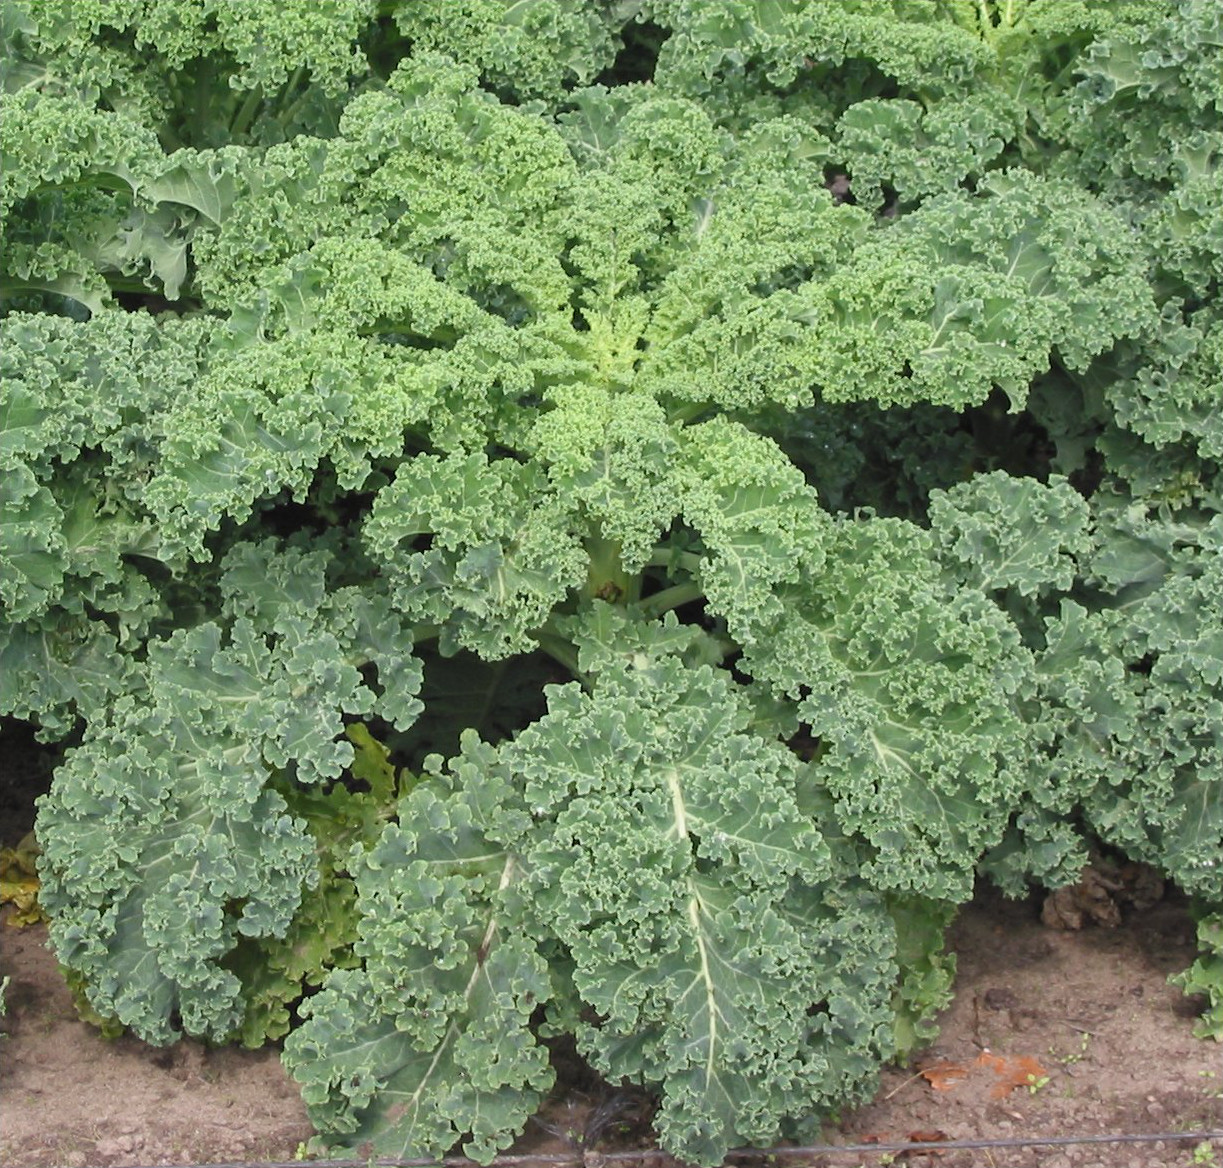

In [12]:
kale_image

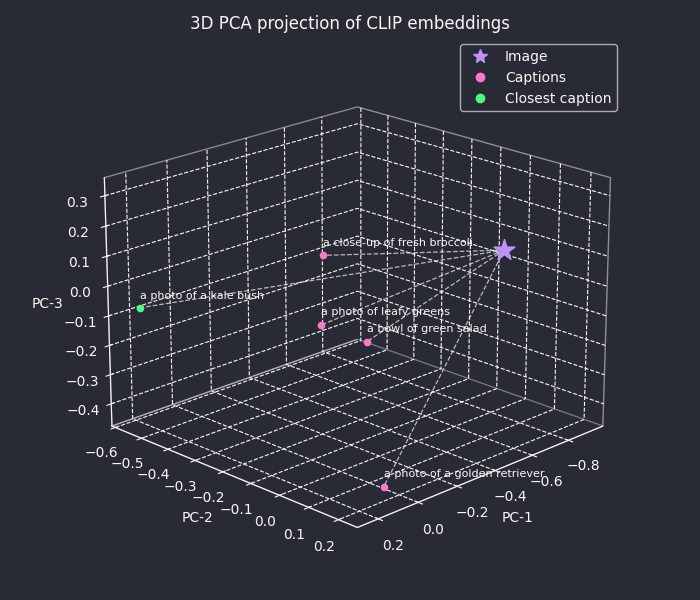

In [26]:
%matplotlib ipympl

# ░░ 3‑D PCA Visualization (3 components) ░░
# Requirements already in memory:
#   img_embed  : tensor (1, D)
#   text_embeds: list[tensor]  (len = N)
#   captions   : list[str]     (len = N)
#   dracula_style imported earlier

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (activates 3‑D backend)
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
import numpy as np

# --- Project embeddings onto 3 principal components ---
all_embeds = torch.cat([img_embed] + text_embeds).cpu().numpy()  # (N+1, D)
pca_3d     = PCA(n_components=3).fit_transform(all_embeds)        # (N+1, 3)

img_xyz = pca_3d[0]    # (x, y, z) for image
cap_xyz = pca_3d[1:]   # (N, 3) captions

# --- Compute Euclidean distances in the 3‑D PCA space ---
dists        = np.linalg.norm(cap_xyz - img_xyz, axis=1)
closest_idx  = np.argmin(dists)

# --- Plotting ---
fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection="3d")
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor(BG_COLOR)
    axis._axinfo["grid"]["color"] = FG_COLOR

# Image (star)
ax.scatter(*img_xyz, marker="*", s=250, label="Image", depthshade=False)

# Captions + lines
for i, (xyz, cap, dist) in enumerate(zip(cap_xyz, captions, dists)):
    is_closest = i == closest_idx
    point_kw   = {"color": GREEN} if cap == "a photo of a kale bush" else {"color": PINK}
    line_kw    = {"color": FG_COLOR, "alpha": 0.7}

    # Point
    ax.scatter(*xyz, zorder=3, depthshade=False, **point_kw)

    # Line (dashed)
    ax.plot([img_xyz[0], xyz[0]],
            [img_xyz[1], xyz[1]],
            [img_xyz[2], xyz[2]],
            linestyle="--",
            linewidth=0.9,
            **line_kw)

    # Caption text (slightly offset in z for readability)
    ax.text(xyz[0], xyz[1], xyz[2] + 0.03, cap, fontsize=8, zorder=4)

    # # Optional: distance annotation at midpoint
    # mid = (img_xyz + xyz) / 2
    # ax.text(mid[0], mid[1], mid[2], f"{dist:.2f}", fontsize=7, ha="center", va="center")

# Axes cosmetics
style_axes(ax)
ax.set_title("3D PCA projection of CLIP embeddings")
ax.set_xlabel("PC‑1")
ax.set_ylabel("PC‑2")
ax.set_zlabel("PC‑3")
ax.view_init(elev=20, azim=45)  # nice vantage

# Custom legend that matches 3‑D markers
legend_handles = [
    Line2D([], [], marker="*", color=PURPLE, linestyle="None", markersize=10, label="Image"),
    Line2D([], [], marker="o", color=PINK, linestyle="None", label="Captions"),
    Line2D([], [], marker="o", color=GREEN,  linestyle="None", label="Closest caption"),
]
ax.legend(handles=legend_handles, loc="best")

plt.tight_layout()


In [2]:
import matplotlib.pyplot as plt

# Dracula theme colors
BG_COLOR = '#282a36'  # Dark background
FG_COLOR = '#f8f8f2'  # Light foreground text
PURPLE   = '#BD93F9'  # Primary color
ORANGE   = '#FFB86C'  # Secondary color
PINK     = '#FF79C6'  # Tertiary color
GREEN    = '#50FA7B'  # Additional color
CYAN     = '#8BE9FD'  # Additional color

plt.rcParams.update(
    {
        "figure.facecolor": BG_COLOR,
        "axes.facecolor"  : BG_COLOR,
        "axes.edgecolor"  : FG_COLOR,
        "axes.labelcolor" : FG_COLOR,
        "xtick.color"     : FG_COLOR,
        "ytick.color"     : FG_COLOR,
        "text.color"      : FG_COLOR,
        "axes.prop_cycle" : plt.cycler(color=[PURPLE, ORANGE, PINK, CYAN, GREEN]),
        "grid.color"      : FG_COLOR,
        "grid.alpha"      : 0.3,
        "grid.linestyle"  : "--",
    }
)

def style_axes(ax, edgecolor=FG_COLOR, linewidth=1.2):
    ax.set_facecolor(BG_COLOR)
    ax.tick_params(colors=FG_COLOR)
    for spine in ax.spines.values():
        spine.set_color(FG_COLOR)
    for patch in ax.patches:
        if hasattr(patch, "get_facecolor"):
            face = patch.get_facecolor()
            patch.set_edgecolor(edgecolor or face)
            patch.set_linewidth(linewidth)


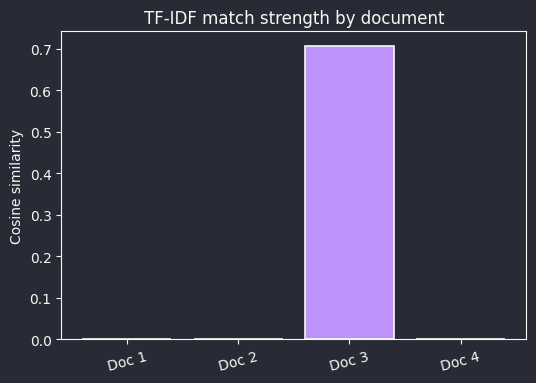

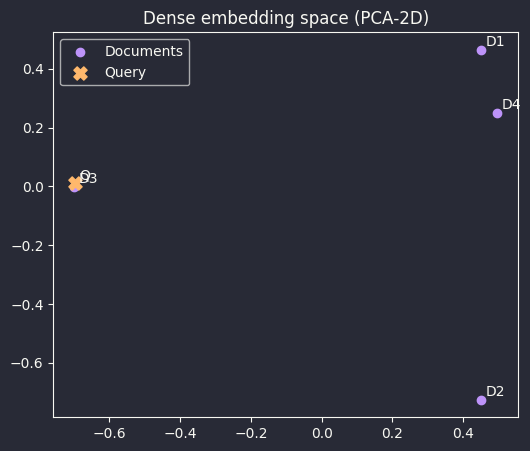

In [13]:
######################################################################
# Imports & shared data ---------------------------------------------
######################################################################
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

# -------------------------------------------------------------------
# A tiny, reusable corpus & query drawn from the post
documents = [
    "Elephants are the largest land mammals on Earth",
    "The Great Wall of China is over 13,000 miles long",
    "Mozart composed his first symphony at age eight",
    "The human body contains approximately 37 trillion cells"
]
query = "When did Mozart compose his first symphony?"
######################################################################

# 1️⃣ Sparse Retrieval — TF‑IDF similarity profile
# Build TF‑IDF matrix
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(documents)
query_vec     = tfidf.transform([query])
similarities  = cosine_similarity(query_vec, tfidf_matrix).flatten()

# Bar chart of similarity scores
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(len(documents)), similarities)
ax.set_xticks(range(len(documents)))
ax.set_xticklabels([f"Doc {i+1}" for i in range(len(documents))], rotation=15)
ax.set_ylabel("Cosine similarity")
ax.set_title("TF‑IDF match strength by document")
style_axes(ax)
plt.show()

# 2️⃣ Dense Retrieval — semantic landscape & score bar
model = SentenceTransformer("all-MiniLM-L6-v2")

# Embeddings
emb_docs  = model.encode(documents)
emb_query = model.encode([query])

# ── 2‑D projection (PCA) ───────────────────────────────────────────
pca = PCA(n_components=2)
coords = pca.fit_transform(np.vstack([emb_docs, emb_query]))

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(coords[:-1, 0], coords[:-1, 1], label="Documents", marker="o")
ax.scatter(coords[-1, 0], coords[-1, 1], label="Query", marker="X", s=90)
for i, (x, y) in enumerate(coords[:-1]):
    ax.annotate(f"D{i+1}", (x, y), textcoords="offset points", xytext=(3, 3))
ax.annotate("Q", (coords[-1, 0], coords[-1, 1]), textcoords="offset points", xytext=(3, 3))
ax.set_title("Dense embedding space (PCA‑2D)")
ax.legend()
style_axes(ax)
plt.show()





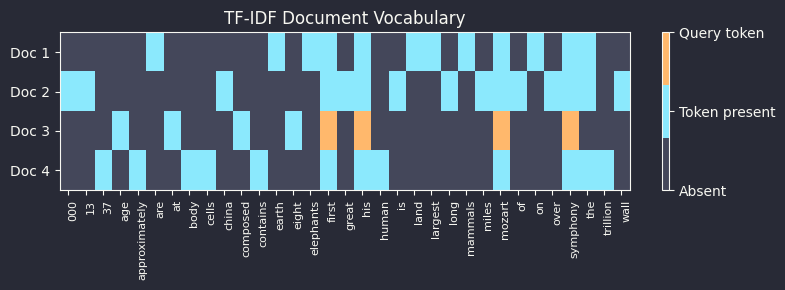

In [12]:
#################################################################
# TRI‑COLOR HEAT‑MAP  ▸  Full‑Vocab Presence Matrix
# 0 = token absent         (dark slate)
# 1 = token present        (cyan)
# 2 = token matches query  (orange)
#################################################################
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.feature_extraction.text import TfidfVectorizer

# --------------------------------------------------------------
# 1.  Corpus & query (same as before)
documents = [
    "Elephants are the largest land mammals on Earth",
    "The Great Wall of China is over 13,000 miles long",
    "Mozart composed his first symphony at age eight",
    "The human body contains approximately 37 trillion cells"
]
query = "When did Mozart compose his first symphony?"

# 2.  Fit vectorizer and build Boolean presence matrix
vectorizer  = TfidfVectorizer()
tfidf_mat   = vectorizer.fit_transform(documents)          # shape: (docs, vocab)
presence    = (tfidf_mat > 0).astype(int).toarray()        # 0/1 matrix
vocab       = vectorizer.get_feature_names_out()

# 3.  Identify vocabulary positions that also occur in the query
query_vec   = vectorizer.transform([query]).toarray().flatten()   # same vocab order
query_mask  = query_vec > 0                                       # Boolean mask

# 4.  Encode 2 for cells where token is in both query & document
presence[:, query_mask] += 1    # converts 0→1 and 1→2 on the masked columns

# 5.  Custom Dracula‑flavored ListedColormap
cmap = ListedColormap([
    '#44475a',   # 0  Absent        (dark slate)
    '#8BE9FD',   # 1  Present       (cyan)
    '#FFB86C'    # 2  Query‑present (orange)
])

# 6.  Plot
fig_height = 3
fig_width  = max(8, 0.10 * len(vocab))      # widen for many tokens
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

img = ax.imshow(presence,
                aspect="auto",
                interpolation="nearest",
                cmap=cmap,
                vmin=0, vmax=2)

# X‑axis: full vocabulary
ax.set_xticks(np.arange(len(vocab)))
ax.set_xticklabels(vocab,
                   rotation=90,
                   ha="left",
                   fontsize=8)

# Y‑axis: documents
ax.set_yticks(np.arange(len(documents)))
ax.set_yticklabels([f"Doc {i+1}" for i in range(len(documents))])

ax.set_title("TF-IDF Document Vocabulary")
style_axes(ax)

# Discrete color bar
cbar = plt.colorbar(img, ax=ax, ticks=[0, 1, 2], fraction=0.046)
cbar.ax.set_yticklabels(["Absent", "Token present", "Query token"])

plt.tight_layout()
plt.show()


Number of chunks: 11

Chunks with overlap:

Chunk 1:
asano naganori 浅野 長矩 september 28 1667 april 21 1701 was the daimyō of the akō domain in japan

Chunk 2:
akō domain in japan 16751701 his title was takumi no kami 内匠頭 he is known as the person who

Chunk 3:
as the person who triggered a series of incidents retold in a story known as chūshingura involving

Chunk 4:
involving the fortyseven rōnin one of the favourite themes of kabuki jōruri and japanese books and

Chunk 5:
japanese books and films on the day of his death he drew his short sword wakizashi and attempted to

Chunk 6:
and attempted to kill kira in the corridor of the pines at edo castle in what is now tokyo he was

Chunk 7:
is now tokyo he was wounded and failed to kill kira on the same day the fifth tokugawa shōgun

Chunk 8:
tokugawa shōgun tsunayoshi sentenced him to commit seppuku which he did after writing his death

Chunk 9:
writing his death poem 風さそう花よりも なお我はまた 春の名残を いかにとやせん kaze sasou hana yori mo nao ware ha mata 

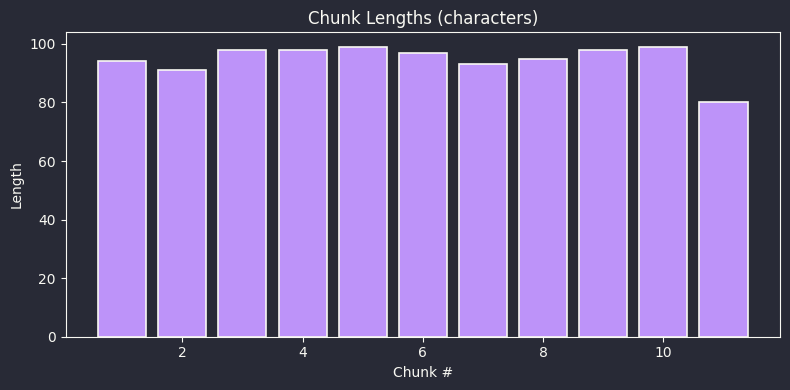

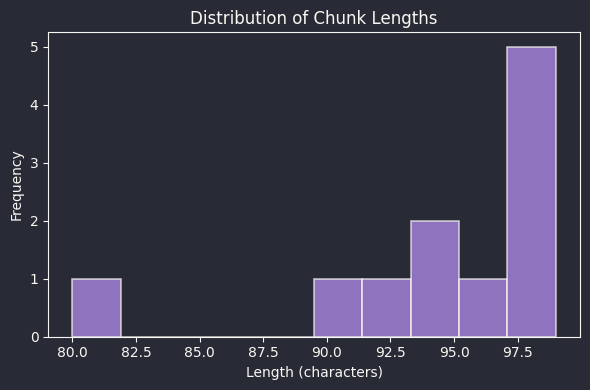

In [16]:
# ------------------------------------------------------------
# RAG BLOG VISUALIZATIONS  |  Dracula theme + style_axes ready
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

# ‑‑‑ 1.  CHUNKING ------------------------------------------------------------

from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.document_loaders import TextLoader
import re

def preprocess_text(text):
    # Normalize case
    text = text.lower()
    # Remove special characters and extra whitespace
    text = re.sub(r'[^\w\s]', '', text)
    text = ' '.join(text.split())
    return text

# Example document
document = """
Asano Naganori (浅野 長矩, September 28, 1667 – April 21, 1701) was the daimyō of the Akō Domain in Japan (1675–1701). His title was Takumi no Kami (内匠頭). He is known as the person who triggered a series of incidents retold in a story known as Chūshingura (involving the forty-seven rōnin), one of the favourite themes of kabuki, jōruri, and Japanese books and films.

On the day of his death, he drew his short sword (Wakizashi) and attempted to kill Kira in the Corridor of the Pines at Edo Castle in what is now Tokyo. He was wounded and failed to kill Kira. On the same day, the fifth Tokugawa shōgun Tsunayoshi sentenced him to commit seppuku, which he did after writing his death poem:

「風さそう花よりも / なお我はまた / 春の名残を / いかにとやせん」

"kaze sasou / hana yori mo nao / ware ha mata / haru no nagori wo / ika ni toyasen."

"More than the cherry blossoms, Inviting a wind to blow them away, I am wondering what to do,

With the remaining springtime."
"""

# Create text splitter with specific chunk size and overlap
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,        # Characters per chunk
    chunk_overlap=20,      # Character overlap between chunks
    length_function=len,
    separators=["\n\n", "\n", " ", ""]  # Priority order for splitting
)

# Preprocess the document
processed_doc = preprocess_text(document)

# Split into chunks
chunks = text_splitter.create_documents([processed_doc])

# Display results
print("Number of chunks:", len(chunks))
print("\nChunks with overlap:")
for i, chunk in enumerate(chunks):
    print(f"\nChunk {i + 1}:")
    print(chunk.page_content)


# Bar chart of chunk lengths (characters)
chunk_lengths = [len(chunk.page_content) for chunk in chunks]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(chunk_lengths) + 1), chunk_lengths)
style_axes(ax)
ax.set_title("Chunk Lengths (characters)")
ax.set_xlabel("Chunk #")
ax.set_ylabel("Length")
plt.tight_layout()

# Histogram of chunk‑length distribution
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(chunk_lengths,
        bins=min(10, len(chunk_lengths)),
        edgecolor=FG_COLOR,
        alpha=0.7)
style_axes(ax)
ax.set_title("Distribution of Chunk Lengths")
ax.set_xlabel("Length (characters)")
ax.set_ylabel("Frequency")
plt.tight_layout()


/var/folders/ll/6ymmghv964ddzxgzk0g867_w0000gn/T/ipykernel_95177/1545387951.py:21: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import OpenAIEmbeddings``.
  embeddings = OpenAIEmbeddings()



Query: Read me Asano Naganori's death poem in English, and then show me the kanji.

Most relevant chunks:
Score: 0.737 | Text: writing his death poem 風さそう花よりも なお我はまた 春の名残を いかにとやせん kaze sasou hana yori mo nao ware ha mata haru
Score: 0.643 | Text: asano naganori 浅野 長矩 september 28 1667 april 21 1701 was the daimyō of the akō domain in japan
Score: 0.635 | Text: japanese books and films on the day of his death he drew his short sword wakizashi and attempted to
Score: 0.626 | Text: tokugawa shōgun tsunayoshi sentenced him to commit seppuku which he did after writing his death


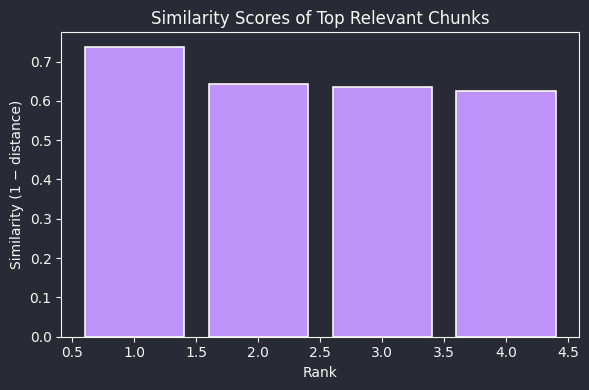

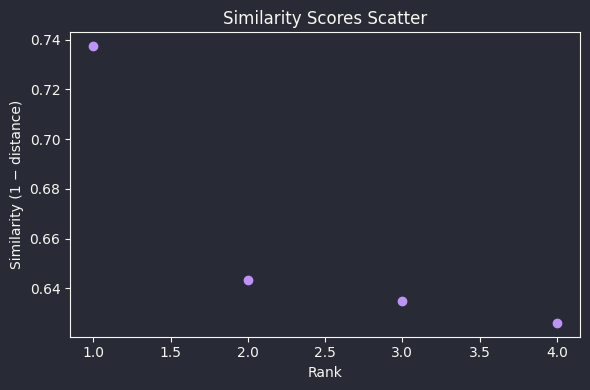

In [17]:

# ‑‑‑ 2.  RELEVANCE FILTERING --------------------------------------------------

from langchain.embeddings import OpenAIEmbeddings
from langchain.vectorstores import FAISS
from langchain.docstore.document import Document

def filter_relevant_chunks(query, chunks, threshold=0.7, top_k=3):
    """
    Filters chunks based on FAISS similarity search, using both a similarity threshold and top-k selection.

    Args:
        query (str): User query string
        chunks (list): List of text chunks
        threshold (float): Minimum similarity score threshold
        top_k (int): Number of top chunks to return

    Returns:
        list: Sorted list of top relevant chunks with similarity scores
    """
    # Initialize embeddings
    embeddings = OpenAIEmbeddings()

    # Create FAISS index
    vectorstore = FAISS.from_documents(chunks, embeddings)

    # Perform similarity search with scores
    docs_and_scores = vectorstore.similarity_search_with_score(query, k=min(top_k, len(chunks)))

    # FAISS returns **distances**, where lower is better. We need to convert it to similarity.
    # Assuming FAISS uses cosine distance, we can convert it to similarity:
    relevant_chunks = [(doc.page_content, 1 - score) for doc, score in docs_and_scores]

    # Filter by similarity threshold
    filtered_chunks = [(text, similarity) for text, similarity in relevant_chunks if similarity >= threshold]

    # Sort by similarity score (descending order)
    top_chunks = sorted(filtered_chunks, key=lambda x: x[1], reverse=True)[:top_k]

    return top_chunks


# Example query
query = "Read me Asano Naganori's death poem in English, and then show me the kanji."

# Get relevant chunks
relevant_chunks = filter_relevant_chunks(
    query=query,
    chunks=chunks,
    threshold=0.5,
    top_k=4
)

# Display results
print("\nQuery:", query)
print("\nMost relevant chunks:")
for text, score in relevant_chunks:
    print(f"Score: {score:.3f} | Text: {text}")


# Bar chart of similarity scores for the top‑K relevant chunks
texts, sim_scores = zip(*relevant_chunks)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, len(sim_scores) + 1), sim_scores)
style_axes(ax)
ax.set_title("Similarity Scores of Top Relevant Chunks")
ax.set_xlabel("Rank")
ax.set_ylabel("Similarity (1 − distance)")
plt.tight_layout()

# Scatter plot as an alternate view
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(range(1, len(sim_scores) + 1), sim_scores, marker="o")
style_axes(ax)
ax.set_title("Similarity Scores Scatter")
ax.set_xlabel("Rank")
ax.set_ylabel("Similarity (1 − distance)")
plt.tight_layout()


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


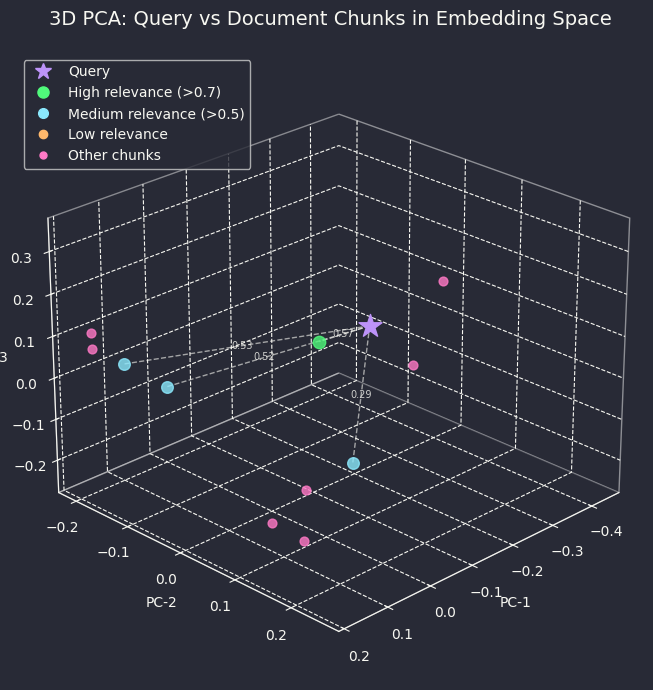

In [22]:
# ░░ 3‑D PCA Visualization for FAISS Similarity Search ░░
# Visualize query and chunks in 3D PCA space

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (activates 3‑D backend)
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
import numpy as np

# --- Get embeddings for query and all chunks ---
embeddings = OpenAIEmbeddings()

# Get query embedding
query_embedding = embeddings.embed_query(query)

# Get embeddings for all chunks (convert Document objects to text if needed)
chunk_texts = [chunk.page_content if hasattr(chunk, 'page_content') else str(chunk) for chunk in chunks]
chunk_embeddings = embeddings.embed_documents(chunk_texts)

# Combine all embeddings
all_embeds = np.array([query_embedding] + chunk_embeddings)  # (N+1, D)

# --- Project embeddings onto 3 principal components ---
pca_3d = PCA(n_components=3).fit_transform(all_embeds)  # (N+1, 3)

query_xyz = pca_3d[0]    # (x, y, z) for query
chunk_xyz = pca_3d[1:]   # (N, 3) for chunks

# --- Compute Euclidean distances in the 3‑D PCA space ---
dists = np.linalg.norm(chunk_xyz - query_xyz, axis=1)

# Get the relevant chunk indices and their similarity scores
relevant_indices = []
relevant_similarities = []
for i, (text, similarity) in enumerate(relevant_chunks):
    # Find which chunk this corresponds to
    for j, chunk_text in enumerate(chunk_texts):
        if chunk_text == text:
            relevant_indices.append(j)
            relevant_similarities.append(similarity)
            break

# --- Plotting ---
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

# Style the 3D plot background
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor(BG_COLOR)
    axis._axinfo["grid"]["color"] = FG_COLOR

# Query (star marker)
ax.scatter(*query_xyz, marker="*", s=300, color=PURPLE, label="Query", depthshade=False, zorder=5)

# Plot all chunks
for i, (xyz, chunk_text, dist) in enumerate(zip(chunk_xyz, chunk_texts, dists)):
    # Check if this chunk is in the relevant results
    is_relevant = i in relevant_indices
    
    if is_relevant:
        # Get similarity score for coloring
        rel_idx = relevant_indices.index(i)
        similarity = relevant_similarities[rel_idx]
        
        # Color based on similarity score (higher = more green, lower = more orange)
        if similarity > 0.7:
            color = GREEN
            size = 80
        elif similarity > 0.5:
            color = CYAN
            size = 70
        else:
            color = ORANGE
            size = 60
            
        label = f"Relevant (sim: {similarity:.2f})"
    else:
        # Non-relevant chunks in pink with smaller size
        color = PINK
        size = 40
        label = "Other chunks"
    
    # Plot chunk point
    ax.scatter(*xyz, color=color, s=size, alpha=0.8, depthshade=False, zorder=3)
    
    # Draw line to query (only for relevant chunks)
    if is_relevant:
        ax.plot([query_xyz[0], xyz[0]],
                [query_xyz[1], xyz[1]], 
                [query_xyz[2], xyz[2]],
                linestyle="--",
                linewidth=1.0,
                color=FG_COLOR,
                alpha=0.6)
        
        # Add distance annotation at midpoint
        mid = (query_xyz + xyz) / 2
        ax.text(mid[0], mid[1], mid[2], f"{dist:.2f}", 
                fontsize=7, ha="center", va="center", color=FG_COLOR, alpha=0.8)

# Style the axes
style_axes(ax)
ax.set_title("3D PCA: Query vs Document Chunks in Embedding Space", fontsize=14, pad=20)
ax.set_xlabel("PC‑1")
ax.set_ylabel("PC‑2")
ax.set_zlabel("PC‑3")
ax.view_init(elev=25, azim=45)  # nice viewing angle

# Custom legend
legend_handles = [
    Line2D([], [], marker="*", color=PURPLE, linestyle="None", markersize=12, label="Query"),
    Line2D([], [], marker="o", color=GREEN, linestyle="None", markersize=8, label="High relevance (>0.7)"),
    Line2D([], [], marker="o", color=CYAN, linestyle="None", markersize=7, label="Medium relevance (>0.5)"),
    Line2D([], [], marker="o", color=ORANGE, linestyle="None", markersize=6, label="Low relevance"),
    Line2D([], [], marker="o", color=PINK, linestyle="None", markersize=5, label="Other chunks"),
]
ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(0, 1))

plt.tight_layout()
plt.show()


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:__main__:index_creation_time: 0.2398
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:__main__:query_time: 0.1740
INFO:__main__:retrieval_time: 0.1740
INFO:__main__:avg_relevance_score: 0.3087
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:__main__:query_time: 0.1907
INFO:__main__:retrieval_time: 0.1907
INFO:__main__:avg_relevance_score: 0.3478



Query: Why was Asano sentenced to commit seppuku?
Score: 0.3087 | Text: On the day of his death, he drew his short sword (Wakizashi) and attempted to kill Kira in the Corridor of the Pines at Edo Castle in what is now Tokyo. He was wounded and failed to kill Kira. On the same day, the fifth Tokugawa shōgun Tsunayoshi sentenced him to commit seppuku, which he did after writing his death poem:

Query: Read me Asano's death poem
Score: 0.3478 | Text: On the day of his death, he drew his short sword (Wakizashi) and attempted to kill Kira in the Corridor of the Pines at Edo Castle in what is now Tokyo. He was wounded and failed to kill Kira. On the same day, the fifth Tokugawa shōgun Tsunayoshi sentenced him to commit seppuku, which he did after writing his death poem:


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:__main__:query_time: 0.2451
INFO:__main__:retrieval_time: 0.2451
INFO:__main__:avg_relevance_score: 0.3467



Query: Was Asano a total bad ass or that?
Score: 0.3467 | Text: Asano Naganori (浅野 長矩, September 28, 1667 – April 21, 1701) was the daimyō of the Akō Domain in Japan (1675–1701). His title was Takumi no Kami (内匠頭). He is known as the person who triggered a series of incidents retold in a story known as Chūshingura (involving the forty-seven rōnin), one of the favourite themes of kabuki, jōruri, and Japanese books and films.


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:__main__:query_time: 0.4100
INFO:__main__:retrieval_time: 0.4100
INFO:__main__:avg_relevance_score: 0.2729


...


Query: When and under what circumstances did Asano first meet Kira?
Score: 0.3208 | Text: In 1701, he was appointed for the second time to the same office. It is said that he was then on bad terms with Kira Yoshinaka, and tension between them increased.


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:__main__:query_time: 0.3451
INFO:__main__:retrieval_time: 0.3451
INFO:__main__:avg_relevance_score: 0.2980
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:__main__:query_time: 0.1801
INFO:__main__:retrieval_time: 0.1801
INFO:__main__:avg_relevance_score: 0.2687



Query: Summarize the illness Asano suffered in 1694 and its implications.
Score: 0.2980 | Text: In 1694, he suffered from a serious illness. He had no children, thus no heir at that time. When a daimyo died without a determined heir, his house would be abolished by the shogunate, and his lands confiscated; his retainers became rōnin. To prevent this, he adopted his younger brother Asano Nagahiro, titled Daigaku, who was accepted as his heir apparent by the shogunate.

Query: What etiquette was required when hosting imperial envoys in the shogun's capital?
Score: 0.2687 | Text: In 1683, he was first appointed one of two officials to host the emissaries from the imperial court to the Shogunate. It was the first time he met Kira Yoshinaka, the highest-ranking kōke, the head of ceremonial matters at the Shogunate, who instructed officials in the manner of hosting noble guests from Kyoto.


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:__main__:query_time: 0.2597
INFO:__main__:retrieval_time: 0.2597
INFO:__main__:avg_relevance_score: 0.4276



Query: How historically accurate is the popular narrative of Chūshingura compared with surviving records?
Score: 0.4276 | Text: These former retainers became famous as the forty-seven rōnin, and their vendetta ranks as one of the most renowned in Japan.

Performance Report:
{'query_times': {'mean': 0.21140402013605292, 'median': 0.19074392318725586, 'p95': 0.38793969154357905, 'p99': 0.41016694068908693}, 'retrieval_times': {'mean': 0.2114032254074559, 'median': 0.19074201583862305, 'p95': 0.38793921470642084, 'p99': 0.41016526222229005}, 'relevance_scores': {'mean': 0.29807755, 'median': 0.29803848, 'p95': 0.38375003933906554, 'p99': 0.41529077887535093}}


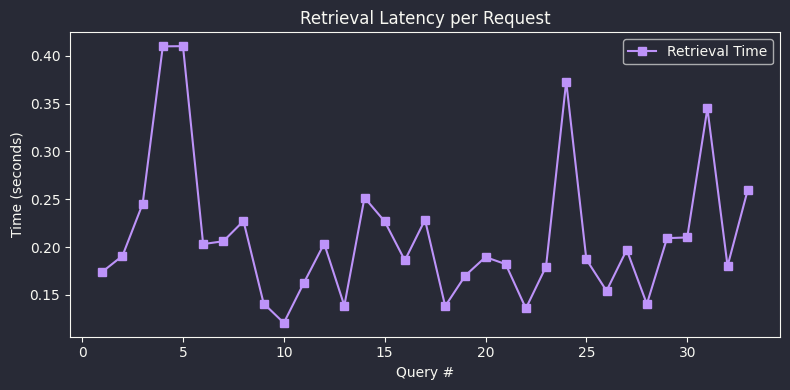

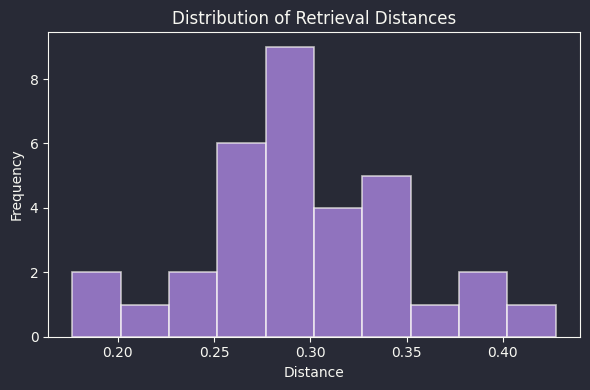

In [28]:
from langchain.embeddings import OpenAIEmbeddings
from langchain.vectorstores import FAISS
import time
import logging
from typing import List, Dict
import numpy as np

class RAGMonitor:
    def __init__(self):
        self.query_times = []
        self.retrieval_times = []
        self.relevance_scores = []
        logging.basicConfig(level=logging.INFO)
        self.logger = logging.getLogger(__name__)

    def log_metrics(self, metric_name: str, value: float):
        self.logger.info(f"{metric_name}: {value:.4f}")

    def calculate_statistics(self, values: List[float]) -> Dict[str, float]:
        return {
            "mean": np.mean(values),
            "median": np.median(values),
            "p95": np.percentile(values, 95),
            "p99": np.percentile(values, 99)
        }

class MonitoredRAG:
    def __init__(self, embeddings, monitor: RAGMonitor):
        self.embeddings = embeddings
        self.monitor = monitor
        self.index = None

    def create_index(self, texts: List[str]):
        start_time = time.time()
        self.index = FAISS.from_texts(texts, self.embeddings)
        index_time = time.time() - start_time
        self.monitor.log_metrics("index_creation_time", index_time)

    def query(self, query_text: str, k: int = 5):
        # Monitor query execution
        query_start = time.time()

        # Get embeddings and search
        retrieval_start = time.time()
        results = self.index.similarity_search_with_score(query_text, k=k)
        retrieval_time = time.time() - retrieval_start

        # Calculate relevance statistics
        scores = [score for _, score in results]

        # Log metrics
        total_time = time.time() - query_start
        self.monitor.query_times.append(total_time)
        self.monitor.retrieval_times.append(retrieval_time)
        self.monitor.relevance_scores.extend(scores)

        # Log current query metrics
        self.monitor.log_metrics("query_time", total_time)
        self.monitor.log_metrics("retrieval_time", retrieval_time)
        self.monitor.log_metrics("avg_relevance_score", np.mean(scores))

        return results

    def get_performance_report(self):
        report = {
            "query_times": self.monitor.calculate_statistics(self.monitor.query_times),
            "retrieval_times": self.monitor.calculate_statistics(self.monitor.retrieval_times),
            "relevance_scores": self.monitor.calculate_statistics(self.monitor.relevance_scores)
        }
        return report

# Initialize
monitor = RAGMonitor()
embeddings = OpenAIEmbeddings()
rag = MonitoredRAG(embeddings, monitor)

# Create index
texts = [
    "Asano Naganori (浅野 長矩, September 28, 1667 – April 21, 1701) was the daimyō of the Akō Domain in Japan (1675–1701). His title was Takumi no Kami (内匠頭). He is known as the person who triggered a series of incidents retold in a story known as Chūshingura (involving the forty-seven rōnin), one of the favourite themes of kabuki, jōruri, and Japanese books and films.",
    "He was born in Edo as the eldest son of Asano Nagatomo. His family was a branch of the Asano clan whose main lineage was in Hiroshima. His grandfather Naganao was appointed to the position of daimyō of Ako with 50 thousand koku. After Naganao died in 1671, Nagatomo succeeded to the position, but died after three years in 1675. Naganori succeeded his father at the age of nine.",
    "In 1680, he was appointed to the office of Takumi no Kami, the head of carpentry at the imperial court, but this office was nominal, as were other offices granted to samurai at that time, and only had an honorific meaning. As a daimyō with a small fief, he was appointed several times to temporary minor offices of the Tokugawa shogunate.",
    "In 1683, he was first appointed one of two officials to host the emissaries from the imperial court to the Shogunate. It was the first time he met Kira Yoshinaka, the highest-ranking kōke, the head of ceremonial matters at the Shogunate, who instructed officials in the manner of hosting noble guests from Kyoto.",
    "In 1694, he suffered from a serious illness. He had no children, thus no heir at that time. When a daimyo died without a determined heir, his house would be abolished by the shogunate, and his lands confiscated; his retainers became rōnin. To prevent this, he adopted his younger brother Asano Nagahiro, titled Daigaku, who was accepted as his heir apparent by the shogunate.",
    "In 1701, he was appointed for the second time to the same office. It is said that he was then on bad terms with Kira Yoshinaka, and tension between them increased.",
    "On the day of his death, he drew his short sword (Wakizashi) and attempted to kill Kira in the Corridor of the Pines at Edo Castle in what is now Tokyo. He was wounded and failed to kill Kira. On the same day, the fifth Tokugawa shōgun Tsunayoshi sentenced him to commit seppuku, which he did after writing his death poem:",
    "「風さそう花よりも / なお我はまた / 春の名残を / いかにとやせん」\n\n\"kaze sasou / hana yori mo nao / ware ha mata / haru no nagori wo / ika ni toyasen.\"\n\n\"More than the cherry blossoms, Inviting a wind to blow them away, I am wondering what to do,\n\nWith the remaining springtime.\"",
    "He was buried in the graveyard of Sengaku-ji. His retainers became ronin when the Shogunate confiscated his fief. Under the leadership of Ōishi Kuranosuke, however, they avenged the death of their lord by killing Kira Yoshinaka at his mansion in Edo on December 15, 1702.",
    "These former retainers became famous as the forty-seven rōnin, and their vendetta ranks as one of the most renowned in Japan."
]
rag.create_index(texts)

# Perform queries
queries = [
    "Why was Asano sentenced to commit seppuku?",
    "Read me Asano's death poem",
    "Was Asano a total bad ass or that?",
    "What sparked the confrontation between Asano Naganori and Kira Yoshinaka?",
    "How old was Asano when he inherited the Akō domain?",
    "Explain the day‑to‑day duties attached to the title Takumi no Kami.",
    "Where is Sengaku‑ji temple located, and why is it famous?",
    "On what exact date did the forty‑seven rōnin avenge their lord?",
    "Who led Asano's former retainers after his death?",
    "Describe the incident in the Corridor of the Pines at Edo Castle.",
    "Why did Asano adopt his younger brother Daigaku (Nagahiro)?",
    "What sentence did Shōgun Tokugawa Tsunayoshi impose on Asano?",
    "Translate Asano’s jisei (death poem) into modern English.",
    "How many koku of rice income did the Akō fief yield?",
    "List all official posts Asano Naganori held in his lifetime.",
    "Which classic kabuki play dramatizes the forty‑seven rōnin story?",
    "What happened to the Akō domain immediately after Asano’s seppuku?",
    "Did Asano Naganori leave any direct descendants?",
    "Contrast the roles of a kōke and a daimyō in Tokugawa Japan.",
    "What was the ceremonial importance of the office “head of carpentry” at court?",
    "Provide a brief biography of Kira Yoshinaka.",
    "Define the term rōnin and explain how men became rōnin.",
    "How were loyal samurai expected to react when their lord lost his lands?",
    "What type of blade did Asano draw against Kira?",
    "Discuss the tradition of composing death poems among samurai.",
    "Name another famous revenge vendetta in Japanese history besides the forty‑seven rōnin.",
    "Show the kanji characters for Asano Naganori’s personal name.",
    "Outline the political fallout of the 1702 vendetta for the Tokugawa shogunate.",
    "How did Edo‑period kabuki portray Asano's seppuku over time?",
    "When and under what circumstances did Asano first meet Kira?",
    "Summarize the illness Asano suffered in 1694 and its implications.",
    "What etiquette was required when hosting imperial envoys in the shogun's capital?",
    "How historically accurate is the popular narrative of Chūshingura compared with surviving records?",
]

for query in queries:
    results = rag.query(query, k=1)
    print(f"\nQuery: {query}")
    for doc, score in results:
        print(f"Score: {score:.4f} | Text: {doc.page_content}")

# Get performance report
report = rag.get_performance_report()
print("\nPerformance Report:")
print(report)


# ‑‑‑ 3.  MONITORING & EVALUATION --------------------------------------------
# Line plot of latency per query
query_times     = rag.monitor.query_times
retrieval_times = rag.monitor.retrieval_times

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(retrieval_times) + 1), retrieval_times,
        marker="s", label="Retrieval Time")
style_axes(ax)
ax.set_title("Retrieval Latency per Request")
ax.set_xlabel("Query #")
ax.set_ylabel("Time (seconds)")
ax.legend()
plt.tight_layout()

# Histogram of retrieval distances (lower = more similar)
relevance_scores = rag.monitor.relevance_scores

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(relevance_scores,
        bins=min(10, len(relevance_scores)),
        edgecolor=FG_COLOR,
        alpha=0.7)
style_axes(ax)
ax.set_title("Distribution of Retrieval Distances")
ax.set_xlabel("Distance")
ax.set_ylabel("Frequency")
plt.tight_layout()

In [29]:
from typing import Literal, TypedDict, Annotated
from langgraph.graph import Graph, START, END
from langchain_core.messages import HumanMessage, AIMessage
from langchain_openai import ChatOpenAI

# Define state
class AgentState(TypedDict):
    messages: list[HumanMessage | AIMessage]
    selected_path: str

# Create LLM
llm = ChatOpenAI(model="gpt-4o-mini")

def route_decision(state) -> Literal["path_a", "path_b"]:
    if "TAKE PATH A" in state["selected_path"]:
        return "path_a"
    elif "TAKE PATH B" in state["selected_path"]:
        return "path_b"
    else:
        raise ValueError(f"Bad response")

# Define nodes
def get_decision(state):
    # Get the last message
    messages = state["messages"]

    # Ask LLM to make a decision
    response = llm.invoke(
        [
            *messages,
            HumanMessage(content="Flip a coin. Then declare 'TAKE PATH A' if you get heads or 'TAKE PATH B' if you get tails. Let me know the result of the coin experiment. Make sure you keep it fair! After you tell me what path to take stop talking.")
        ]
    )

    # Update state with decision
    state["selected_path"] = response.content
    return state

def path_a(state):
    response = llm.invoke(
        [
            *state["messages"],
            HumanMessage(content="Better to stay home. Justify why this makes sense.")
        ]
    )
    state["messages"].append(response)
    return state

def path_b(state):
    response = llm.invoke(
        [
            *state["messages"],
            HumanMessage(content="Go to Japan. Justify why this makes sense.")
        ]
    )
    state["messages"].append(response)
    return state

# Create workflow
workflow = Graph()

# Add nodes
workflow.add_node("decision", get_decision)
workflow.add_node("path_a", path_a)
workflow.add_node("path_b", path_b)

workflow.add_edge(START, "decision")

# Add conditional edges
workflow.add_conditional_edges(
    "decision",
    route_decision,
)

# Add end
workflow.add_edge("path_a", END)
workflow.add_edge("path_b", END)

# Compile
graph = workflow.compile()

# Run example
response = graph.invoke({
    "messages": [
        HumanMessage(content="I want to go on vacation but I only have $500")
    ],
    "selected_path": ""
})

print("\nFinal Response:")
print(response["messages"][-1].content)



INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"



Final Response:
While the idea of going on vacation can be exciting, choosing to stay home with a budget of $500 can actually be a reasonable and rewarding decision for several reasons:

1. **Cost-Effectiveness**: Traveling often includes costs beyond just transportation, such as accommodation, meals, and activities. With $500, you might find it challenging to cover all expenses for a trip, especially if you're considering flights or staying in hotels.

2. **Local Exploration**: Staying home allows you to explore your local area or nearby attractions. You might discover hidden gems, parks, or cultural sites you haven't visited before, enriching your experience without the costs associated with traveling.

3. **Reducing Stress**: Planning a vacation can often be stressful with logistics, packing, and travel arrangements. Staying home can provide a relaxing and stress-free environment where you can unwind without the pressures of travel.

4. **Quality Time**: You can use your budget to 

/Users/alex/pro/ai-engineer-roadmap-notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128256 (\N{TWISTED RIGHTWARDS ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


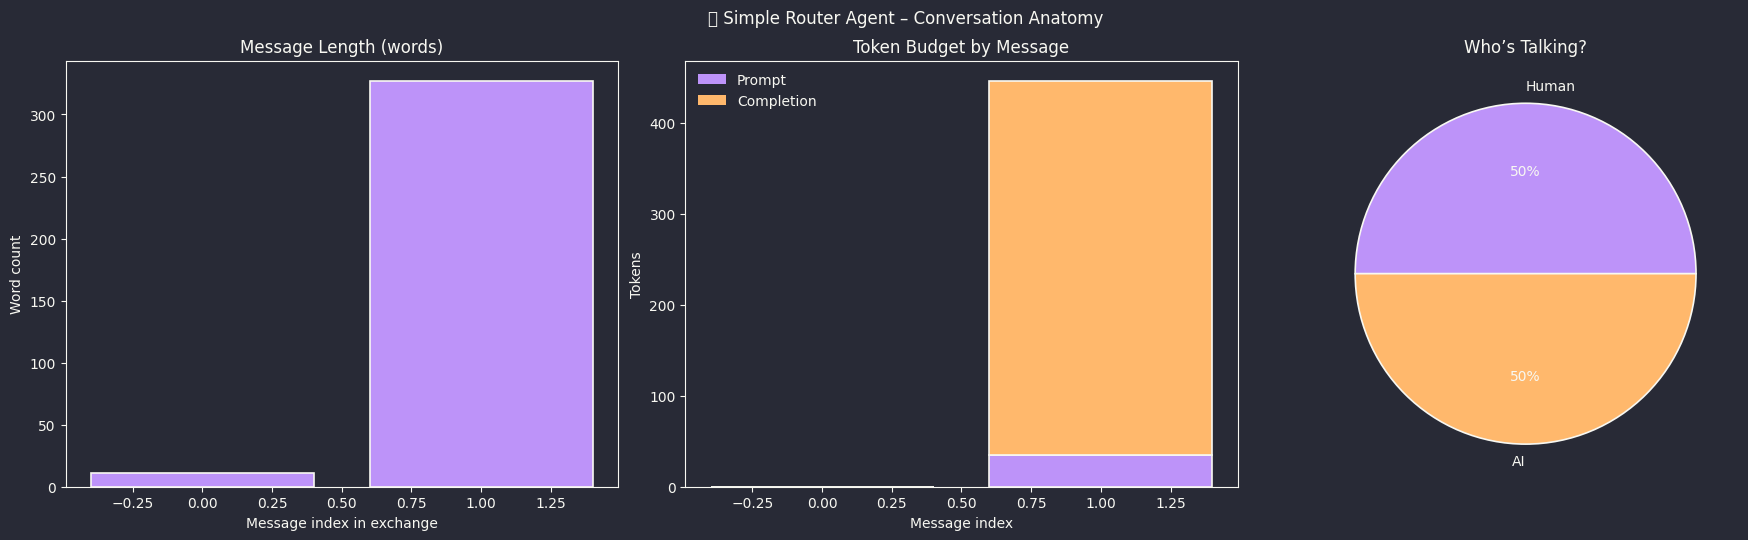

In [31]:
######################################################################
# 📊 VISUALIZATIONS FOR THE SIMPLE ROUTER AGENT
# ‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑
# Assumptions:
#   • You executed the router‑agent demo exactly as in the blog, so the
#     LangGraph output is still in `response`.
#   • If you renamed that variable, assign it to `router_response`
#     before running this cell.
######################################################################

from langchain_core.messages import HumanMessage, AIMessage
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------------------------------------------
# 1) Normalise the variable name – handy if you’ve got several demos
# -------------------------------------------------------------------
try:
    router_response         # was this set explicitly?
except NameError:
    try:
        router_response = response   # same name as in the blog snippet
    except NameError as e:
        raise NameError(
            "❌ Couldn’t find the router‑agent output. "
            "Make sure the router example ran first and the result is "
            "still accessible (e.g. in a variable called `response` "
            "or `router_response`)."
        ) from e

# -------------------------------------------------------------------
# 2) Massage the message objects into a tidy DataFrame
# -------------------------------------------------------------------
records = []
for idx, msg in enumerate(router_response["messages"]):
    role = "Human" if isinstance(msg, HumanMessage) else "AI"
    word_count = len(msg.content.split())

    # Token usage metadata is only present on *assistant* messages
    tok = getattr(msg, "response_metadata", {}).get("token_usage", {})
    records.append(
        {
            "Step": idx,
            "Role": role,
            "WordCount": word_count,
            "PromptTokens": tok.get("prompt_tokens", 0),
            "CompletionTokens": tok.get("completion_tokens", 0),
        }
    )

df_router = pd.DataFrame(records)

# -------------------------------------------------------------------
# 3) Prepare a figure with three sub‑plots
# -------------------------------------------------------------------
fig, axes = plt.subplots(
    1, 3, figsize=(18, 5), constrained_layout=True
)

# --- (A) Words per message -----------------------------------------
axes[0].bar(df_router["Step"], df_router["WordCount"])
axes[0].set_title("Message Length (words)")
axes[0].set_xlabel("Message index in exchange")
axes[0].set_ylabel("Word count")
style_axes(axes[0])

# --- (B) Token usage stacked bar -----------------------------------
bottom = df_router["PromptTokens"]
axes[1].bar(df_router["Step"], df_router["PromptTokens"], label="Prompt")
axes[1].bar(
    df_router["Step"], df_router["CompletionTokens"],
    bottom=bottom, label="Completion"
)
axes[1].set_title("Token Budget by Message")
axes[1].set_xlabel("Message index")
axes[1].set_ylabel("Tokens")
axes[1].legend(frameon=False)
style_axes(axes[1])

# --- (C) Human vs AI proportion ------------------------------------
counts = df_router["Role"].value_counts()
axes[2].pie(
    counts,
    labels=counts.index,
    autopct="%1.0f%%",
    wedgeprops={"linewidth": 1.0, "edgecolor": FG_COLOR},
    textprops={"color": FG_COLOR},
)
axes[2].set_title("Who’s Talking?")
style_axes(axes[2])

plt.suptitle("🔀 Simple Router Agent – Conversation Anatomy", y=1.05)
plt.show()

In [32]:
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI
import math

model = ChatOpenAI(model="gpt-4o", temperature=0)

# Importing required modules
from langchain_core.tools import tool

@tool
def square_root(number: float) -> float:
    """Calculates the square root of a given number."""
    if number < 0:
        return "Error: Cannot calculate the square root of a negative number."
    return math.sqrt(number)

@tool
def square(number: float) -> float:
    """Calculates the square of a given number."""
    return number * number

# Assign the tool to the tools list
tools = [square_root, square]

# Define the graph
graph = create_react_agent(model, tools=tools)

inputs = {"messages": [("user", "calculate the hypotenuse of a triangle with sides 5 x 8")]}
for message in graph.stream(inputs):
    print(message)

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


{'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_BR09L0E0NVMJKjKPpGTiDojr', 'function': {'arguments': '{"number": 5}', 'name': 'square'}, 'type': 'function'}, {'id': 'call_jVQEyvwPfsRu66F6Y5GjigHg', 'function': {'arguments': '{"number": 8}', 'name': 'square'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 82, 'total_tokens': 124, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_a288987b44', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--b092a477-0396-43b4-892a-8ccdbe1a7374-0', tool_calls=[{'name': 'square', 'args': {'number': 5}, 'id': 'call_BR09L0E0NVMJKjKPpGTiDojr', 'type': 'tool_call'}, {'name': 'square', 'args': {'number': 8}, 'id': 'call_jVQE

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


{'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_xSDElzTc15uNz0xP0ak18Y8U', 'function': {'arguments': '{"number":89.0}', 'name': 'square_root'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 144, 'total_tokens': 160, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_a288987b44', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--80a32d60-abfb-4e96-8e0b-266206c2c580-0', tool_calls=[{'name': 'square_root', 'args': {'number': 89.0}, 'id': 'call_xSDElzTc15uNz0xP0ak18Y8U', 'type': 'tool_call'}], usage_metadata={'input_tokens': 144, 'output_tokens': 16, 'total_tokens': 160, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


{'agent': {'messages': [AIMessage(content='The hypotenuse of a triangle with sides 5 and 8 is approximately 9.43.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 175, 'total_tokens': 197, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_a288987b44', 'finish_reason': 'stop', 'logprobs': None}, id='run--7c2f5e7a-cb3e-4853-bb23-57cc446a14ab-0', usage_metadata={'input_tokens': 175, 'output_tokens': 22, 'total_tokens': 197, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}


In [34]:
tool_stream = list(graph.stream(inputs))

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


In [44]:
tool_stream

[{'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_oWBZZMel1CMdMBs5PGVqENnz', 'function': {'arguments': '{"number": 5}', 'name': 'square'}, 'type': 'function'}, {'id': 'call_7otuKx7aMxBgFGvVcP3RyBAD', 'function': {'arguments': '{"number": 8}', 'name': 'square'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 82, 'total_tokens': 124, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_a288987b44', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--677eebdb-f4b2-4435-b68e-ef9778b3ebe3-0', tool_calls=[{'name': 'square', 'args': {'number': 5}, 'id': 'call_oWBZZMel1CMdMBs5PGVqENnz', 'type': 'tool_call'}, {'name': 'square', 'args': {'number': 8}, 'id': 'call_7ot

{'id': 'call_oWBZZMel1CMdMBs5PGVqENnz', 'function': {'arguments': '{"number": 5}', 'name': 'square'}, 'type': 'function'}
{'id': 'call_7otuKx7aMxBgFGvVcP3RyBAD', 'function': {'arguments': '{"number": 8}', 'name': 'square'}, 'type': 'function'}
{'id': 'call_FznvBxlnGWJCHuRTAHkVtbI7', 'function': {'arguments': '{"number":89.0}', 'name': 'square_root'}, 'type': 'function'}


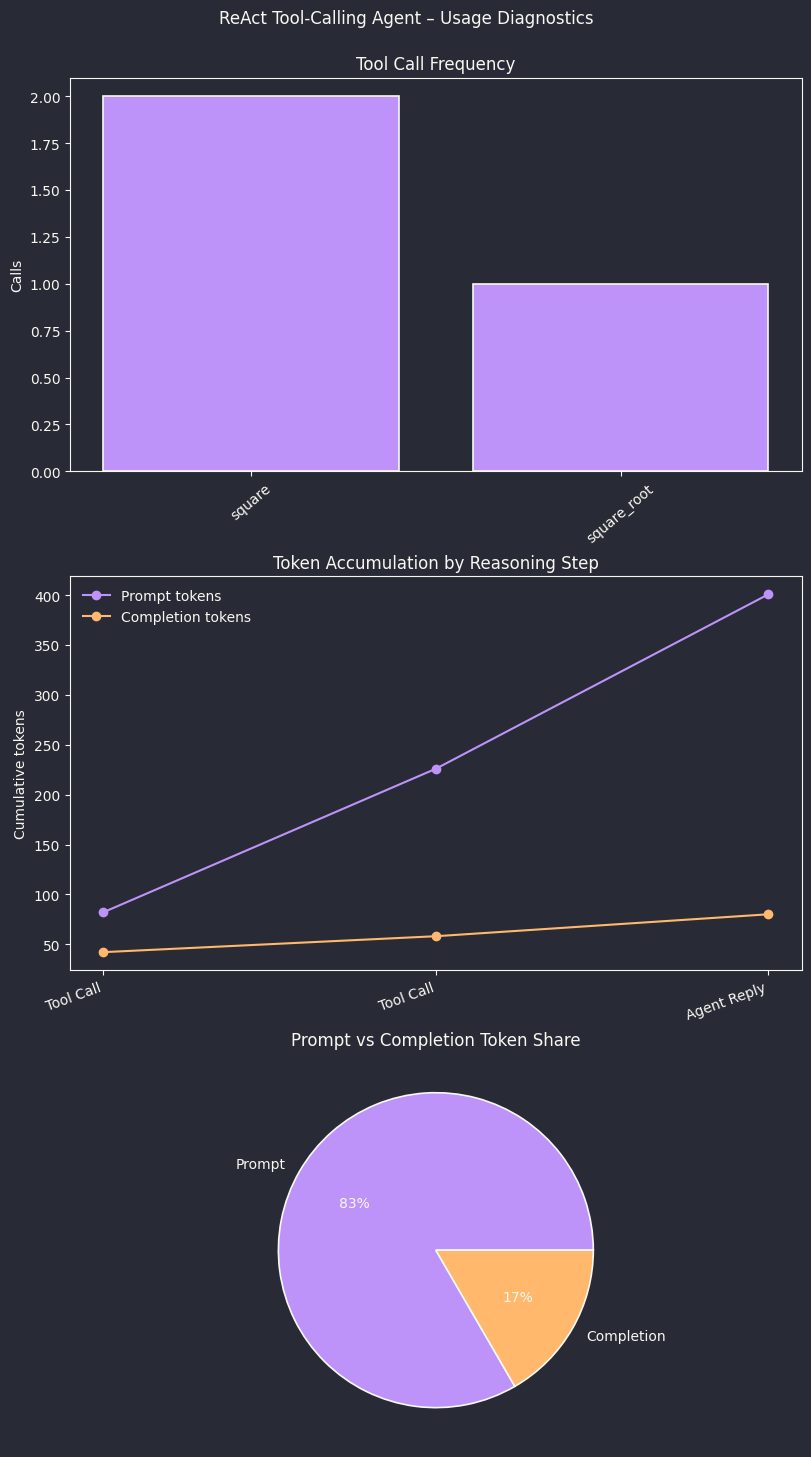

In [45]:
######################################################################
# 📊  VERTICALLY‑STACKED VISUALIZATIONS FOR THE TOOL‑CALLING (ReAct) AGENT
# ‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑
# Prerequisite: `tool_stream` is a list of packets from
#               tool_stream = list(graph.stream(inputs))
######################################################################

import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------------------------------------------
# 0) Safety guard: ensure `tool_stream` exists
# -------------------------------------------------------------------
try:
    tool_stream
except NameError as e:
    raise NameError(
        "❌ Couldn’t find `tool_stream`. "
        "Run the ReAct agent again with "
        "`tool_stream = list(graph.stream(inputs))`."
    ) from e

# -------------------------------------------------------------------
# 1) Parse stream → token usage, tool counts, and call‑type labels
# -------------------------------------------------------------------
tool_counter   = {}
steps          = []
cum_prompt     = cum_completion = 0

def infer_call_type(agent_msg):
    """Return a short call‑type string for x‑axis labelling."""
    if agent_msg.additional_kwargs.get("tool_calls"):
        return "Tool Call️"
    # If the final assistant reply has no tool_calls, treat as plain agent
    return "Agent Reply"

for step_idx, packet in enumerate(tool_stream):
    # We only care about packets that contain an "agent" key
    if "agent" not in packet:
        # (Packets with the "tools" key are echoes of tool results, skip.)
        continue

    agent_msg = packet["agent"]["messages"][-1]
    tok       = agent_msg.response_metadata.get("token_usage", {})
    cum_prompt      += tok.get("prompt_tokens", 0)
    cum_completion  += tok.get("completion_tokens", 0)

    # Tally individual tool invocations
    for call in agent_msg.additional_kwargs.get("tool_calls", []):
        print(call)
        name = call["function"]["name"]
        tool_counter[name] = tool_counter.get(name, 0) + 1

    steps.append(
        {
            "Step"              : step_idx,
            "CallType"          : infer_call_type(agent_msg),
            "CumulativePrompt"  : cum_prompt,
            "CumulativeCompletion": cum_completion,
        }
    )

df_steps = pd.DataFrame(steps)
df_tools = pd.Series(tool_counter, name="Calls").sort_values(ascending=False)

# -------------------------------------------------------------------
# 2) Create THREE stacked sub‑plots (vertical layout)
# -------------------------------------------------------------------
fig, axes = plt.subplots(
    3,          # rows
    1,          # cols
    figsize=(8, 14),
    constrained_layout=True,
    sharex=False
)

# === (A) Calls per tool ============================================
axes[0].bar(df_tools.index, df_tools.values)
axes[0].set_title("Tool Call Frequency")
# axes[0].set_xlabel("Tool name")
axes[0].set_ylabel("Calls")
for tick in axes[0].get_xticklabels():
    tick.set_rotation(40)
style_axes(axes[0])

# === (B) Cumulative token usage with custom x‑axis labels ==========
axes[1].plot(df_steps["Step"], df_steps["CumulativePrompt"],
             marker="o", label="Prompt tokens")
axes[1].plot(df_steps["Step"], df_steps["CumulativeCompletion"],
             marker="o", label="Completion tokens")
axes[1].set_title("Token Accumulation by Reasoning Step")
# axes[1].set_xlabel("Reasoning step")
axes[1].set_ylabel("Cumulative tokens")

# Apply descriptive call‑type labels to every tick
axes[1].set_xticks(df_steps["Step"])
axes[1].set_xticklabels(
    df_steps["CallType"],
    rotation=20,
    ha="right"
)
axes[1].legend(frameon=False)
style_axes(axes[1])

# === (C) Prompt vs completion share pie ============================
final_prompt     = df_steps["CumulativePrompt"].iloc[-1]
final_completion = df_steps["CumulativeCompletion"].iloc[-1]
axes[2].pie(
    [final_prompt, final_completion],
    labels=["Prompt", "Completion"],
    autopct="%1.0f%%",
    wedgeprops={"linewidth": 1.0, "edgecolor": FG_COLOR},
    textprops={"color": FG_COLOR},
)
axes[2].set_title("Prompt vs Completion Token Share")
style_axes(axes[2])

plt.suptitle("ReAct Tool‑Calling Agent – Usage Diagnostics", y=1.03)
plt.show()


In [ ]:
######################################################################
# 📊 VISUALIZATIONS FOR THE MULTI‑STEP TRAVEL PLANNER AGENT
# ‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑‑
# Assumptions:
#   • You ran the travel‑planner demo and its `graph.invoke(...)`
#     return value is still in `response`.
#   • If you reused the name `response` earlier, rename one of them or
#     assign the travel response to `travel_response`.
######################################################################

from langchain_core.messages import HumanMessage, AIMessage
import matplotlib.pyplot as plt
import pandas as pd

try:
    travel_response
except NameError:
    try:
        travel_response = response   # hopefully the newest overwrite
    except NameError as e:
        raise NameError(
            "❌ Couldn’t find the travel‑planner output. "
            "Assign it to `travel_response` (or leave it in `response` "
            "if that variable hasn’t been reused)."
        ) from e

# -------------------------------------------------------------------
# 1) Boolean state → tidy format
# -------------------------------------------------------------------
state_flags = {
    "Budget confirmed"     : travel_response.get("budget_confirmed", False),
    "Destination confirmed": travel_response.get("destination_confirmed", False),
    "Dates confirmed"      : travel_response.get("dates_confirmed", False),
}
df_state = pd.Series(state_flags, name="Success").astype(int)

# -------------------------------------------------------------------
# 2) Token + word metrics for every message
# -------------------------------------------------------------------
records = []
for idx, msg in enumerate(travel_response["messages"]):
    role = "Human" if isinstance(msg, HumanMessage) else "AI"
    tok  = getattr(msg, "response_metadata", {}).get("token_usage", {})
    records.append(
        {
            "Step": idx,
            "Role": role,
            "WordCount": len(msg.content.split()),
            "PromptTokens": tok.get("prompt_tokens", 0),
            "CompletionTokens": tok.get("completion_tokens", 0),
        }
    )

df_travel = pd.DataFrame(records)

# -------------------------------------------------------------------
# 3) Figure with three sub‑plots
# -------------------------------------------------------------------
fig, axes = plt.subplots(
    1, 3, figsize=(18, 5), constrained_layout=True
)

# --- (A) Binary state bar chart -------------------------------------
axes[0].barh(df_state.index, df_state.values)
axes[0].set_title("✅ Planner State Flags")
axes[0].set_xlim(0, 1)
axes[0].set_xticks([0, 1], ["False", "True"])
style_axes(axes[0])

# --- (B) Token usage per message ------------------------------------
axes[1].bar(df_travel["Step"], df_travel["PromptTokens"], label="Prompt")
axes[1].bar(
    df_travel["Step"], df_travel["CompletionTokens"],
    bottom=df_travel["PromptTokens"], label="Completion"
)
axes[1].set_title("🪙 Tokens by Planner Step")
axes[1].set_xlabel("Message index")
axes[1].set_ylabel("Tokens")
axes[1].legend(frameon=False)
style_axes(axes[1])

# --- (C) Word count trend -------------------------------------------
axes[2].plot(df_travel["Step"], df_travel["WordCount"], marker="o")
axes[2].set_title("📝 Verbosity Over Time")
axes[2].set_xlabel("Message index")
axes[2].set_ylabel("Word count")
style_axes(axes[2])

plt.suptitle("🌍 Multi‑Step Travel Planner – Execution Metrics", y=1.05)
plt.show()
